# EDA

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
import os
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import missingno as msno
import ipywidgets as widgets

In [2]:
df = pd.read_csv("../scripts/data/matches_sq.csv")
df

/tmp/ipykernel_137984/353670935.py:1: DtypeWarning: Columns (0: Referee, 1: Time, 2: B365CH) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../scripts/data/matches_sq.csv")


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AwayTeam_sq_def_mean,AwayTeam_sq_def_top_mean,AwayTeam_sq_def_top3_mean,AwayTeam_sq_mid_mean,AwayTeam_sq_mid_top_mean,AwayTeam_sq_mid_top3_mean,AwayTeam_sq_att_mean,AwayTeam_sq_att_top_mean,AwayTeam_sq_att_top3_mean,AwayTeam_sq_mapped
0,E0,13/08/16,Burnley,Swansea,0,1,A,0.0,0.0,D,...,71.300000,79.0,77.000000,70.538462,82.0,79.666667,68.833333,80.0,78.000000,1
1,E0,13/08/16,Crystal Palace,West Brom,0,1,A,0.0,0.0,D,...,68.600000,79.0,77.666667,70.583333,80.0,78.000000,73.500000,80.0,76.666667,1
2,E0,13/08/16,Everton,Tottenham,1,1,D,1.0,0.0,H,...,72.545455,85.0,83.000000,73.133333,84.0,82.333333,74.000000,84.0,74.000000,1
3,E0,13/08/16,Hull,Leicester,2,1,H,1.0,0.0,H,...,71.272727,80.0,79.000000,71.363636,85.0,81.000000,72.428571,83.0,81.000000,1
4,E0,13/08/16,Man City,Sunderland,2,1,H,1.0,0.0,H,...,70.600000,78.0,77.000000,72.285714,79.0,78.000000,67.400000,80.0,72.333333,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30177,B1,23/05/2026,Oud-Heverlee Leuven,Genk,0,2,A,0.0,2.0,A,...,67.666667,76.0,75.333333,71.363636,78.0,77.000000,67.400000,72.0,70.333333,1
30178,B1,23/05/2026,Standard,Charleroi,0,2,A,0.0,0.0,D,...,66.857143,71.0,69.666667,67.888889,73.0,71.666667,61.600000,68.0,65.333333,1
30179,B1,24/05/2026,Club Brugge,Gent,5,0,H,3.0,0.0,H,...,66.888889,73.0,71.333333,68.000000,73.0,72.000000,67.500000,72.0,69.333333,1
30180,B1,24/05/2026,St Truiden,Mechelen,3,0,H,2.0,0.0,H,...,63.750000,68.0,67.000000,65.454545,74.0,71.666667,66.250000,73.0,69.000000,1


In [3]:
pd.set_option('display.max_info_columns', 300)
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 40)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30182 entries, 0 to 30181
Data columns (total 222 columns):
 #    Column                     Non-Null Count  Dtype  
---   ------                     --------------  -----  
 0    Div                        30182 non-null  str    
 1    Date                       30182 non-null  str    
 2    HomeTeam                   30182 non-null  str    
 3    AwayTeam                   30182 non-null  str    
 4    FTHG                       30182 non-null  int64  
 5    FTAG                       30182 non-null  int64  
 6    FTR                        30182 non-null  str    
 7    HTHG                       30143 non-null  float64
 8    HTAG                       30143 non-null  float64
 9    HTR                        30143 non-null  str    
 10   Referee                    3800 non-null   str    
 11   HS                         28985 non-null  float64
 12   AS                         28985 non-null  float64
 13   HST                        28985 non-nul

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
FTHG,30182.0,1.56,1.31,0.00,1.00,1.00,2.00,10.00
FTAG,30182.0,1.25,1.18,0.00,0.00,1.00,2.00,13.00
HTHG,30143.0,0.69,0.84,0.00,0.00,0.00,1.00,6.00
HTAG,30143.0,0.55,0.76,0.00,0.00,0.00,1.00,7.00
HS,28985.0,13.52,5.37,0.00,10.00,13.00,17.00,46.00
AS,28985.0,11.13,4.79,0.00,8.00,11.00,14.00,45.00
HST,28985.0,4.89,2.61,0.00,3.00,5.00,6.00,20.00
AST,28985.0,4.03,2.37,0.00,2.00,4.00,5.00,23.00
HF,28505.0,12.34,4.10,0.00,9.00,12.00,15.00,33.00
AF,28505.0,12.55,4.12,0.00,10.00,12.00,15.00,34.00


In [5]:
df.describe(include="object")

/tmp/ipykernel_137984/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Div,Date,HomeTeam,AwayTeam,FTR,HTR,Referee,Time,B365CH
count,30182,30182,30182,30182,30182,30143,3800,21230,21200.00
unique,9,2152,280,280,3,3,50,47,258.00
top,E0,22/12/2018,Crystal Palace,Tottenham,H,D,A Taylor,20:00,2.05
freq,3800,53,190,190,13371,12140,295,2033,418.00


Como se observa en información del dataframe, vemos que existen atributos con los nombres `Unnamed: 105`, `Unnamed: 119`, `Unnamed: 120` en los cuales sus respectivas columnas estan vacias, por lo cual vamos a eliminarlas.

In [6]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["Unnamed: 105", "Unnamed: 119", "Unnamed: 120"])
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 30182 entries, 0 to 30181
Data columns (total 219 columns):
 #    Column                     Non-Null Count  Dtype  
---   ------                     --------------  -----  
 0    Div                        30182 non-null  str    
 1    Date                       30182 non-null  str    
 2    HomeTeam                   30182 non-null  str    
 3    AwayTeam                   30182 non-null  str    
 4    FTHG                       30182 non-null  int64  
 5    FTAG                       30182 non-null  int64  
 6    FTR                        30182 non-null  str    
 7    HTHG                       30143 non-null  float64
 8    HTAG                       30143 non-null  float64
 9    HTR                        30143 non-null  str    
 10   Referee                    3800 non-null   str    
 11   HS                         28985 non-null  float64
 12   AS                         28985 non-null  float64
 13   HST                        28985 non-nul

Como vemos tenemos muchos atributos de cuotas por datos, entonces vamos a revisar como se distribuyen estas variables

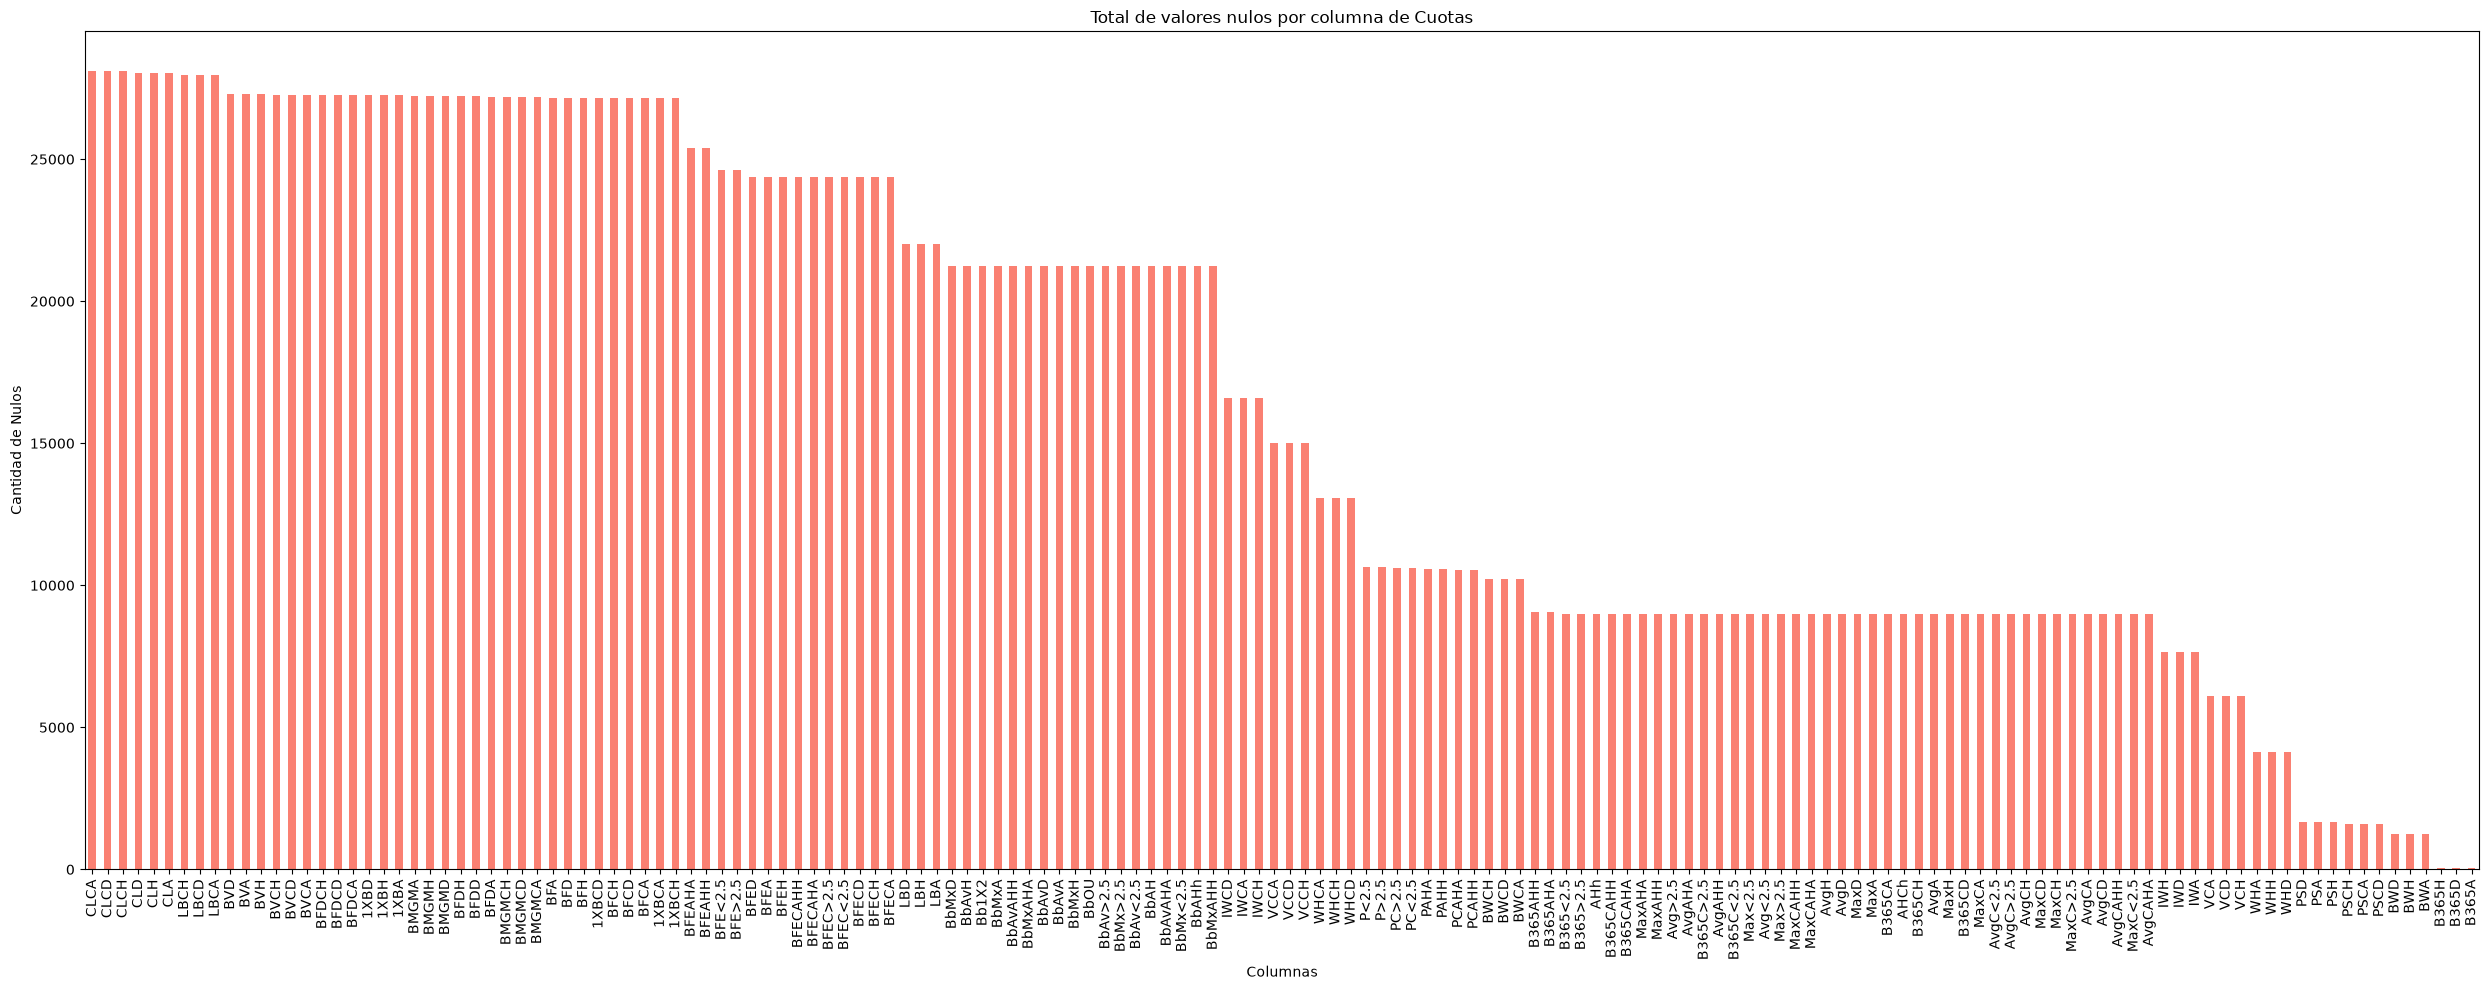

In [7]:
CUOTAS = ['B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA',
          'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5',
          'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 
          'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH',
          'PAHA', 'MaxAHH','MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'WHCH', 'WHCD',
          'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 
          'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'BFH', 'BFD', 
          'BFA', '1XBH', '1XBD', '1XBA', 'BFEH', 'BFED', 'BFEA', 'BFE>2.5', 'BFE<2.5', 'BFEAHH', 'BFEAHA', 'BFCH', 'BFCD', 'BFCA', '1XBCH', '1XBCD', '1XBCA', 
          'BFECH', 'BFECD', 'BFECA', 'BFEC>2.5', 'BFEC<2.5', 'BFECAHH', 'BFECAHA', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 
          'CLH', 'CLD', 'CLA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA']
          
nulos_por_columna = df_clean[CUOTAS].isnull().sum()

nulos_por_columna = nulos_por_columna[nulos_por_columna > 0]

plt.figure(figsize=(25, 10))
nulos_por_columna.sort_values(ascending=False).plot(kind='bar', color='salmon')

plt.title('Total de valores nulos por columna de Cuotas')
plt.ylabel('Cantidad de Nulos')
plt.xlabel('Columnas')
plt.xticks(rotation=90) # Rota las etiquetas para que se puedan leer
plt.tight_layout()
plt.show()

Como vemos tenemos cuotas con más de 15k de datos nulos que sería la mitad de nuestro dataset, y estimar o promediar estariamos generando ruido. Por lo que vamos a eliminar los que superen 12k de datos nulos (40% de nuestro dataset)

In [8]:
len(CUOTAS)

156

In [9]:
umbral = len(df_clean) * 0.4
for n in nulos_por_columna.index:
    if nulos_por_columna[n] > umbral:
        df_clean = df_clean.drop(columns=[n])
        CUOTAS.remove(n)

In [10]:
len(CUOTAS)

73

Ahora con los atributos que tienen datos nulos entre 20% y 40% vamos a transformar esas columnas en variables binarias que indiquen la ausencia del dato antes de desechar la columna numérica original (las que superan 40% ya se eliminaron). De esta forma, capturas la señal estadística de por qué la casa de apuestas decidió suspender o no ofrecer ese mercado (como anomalías financieras, partidos oscuros o lesiones) sin introducir ruido matemático.

In [11]:
umbral2 = len(df_clean) * 0.20
columnas_criticas = [col for col in CUOTAS if umbral2 < df_clean[col].isnull().sum() <= umbral]

for col in columnas_criticas:
    df_clean[f"{col}_Ausente"] = df_clean[col].isnull().astype(int)
    df_clean = df_clean.drop(columns=[col])
    CUOTAS.remove(col)

print(f"Se transformaron y eliminaron {len(columnas_criticas)} columnas problemáticas.")

Se transformaron y eliminaron 58 columnas problemáticas.


Ahora con los atributos que quedan (datos nulos <= 20%) vamos a imputar usando la función `KNNImputer`, ya que esta es una estrategia usa las cuotas de diferentes casas de apuestas están altamente correlacionadas. Si falta la cuota de una casa, el algoritmo buscará partidos con cuotas similares en las casas disponibles para estimar el valor faltante con una precisión alta.

In [12]:
columnas_a_imputar = [col for col in CUOTAS if df_clean[col].isnull().sum() > 0 and df_clean[col].isnull().sum() <= umbral2 and df_clean[col].dtype in [np.float64, np.int64]]
scaler = StandardScaler()
df_clean[columnas_a_imputar] = scaler.fit_transform(df_clean[columnas_a_imputar])
imputer = KNNImputer(n_neighbors=5)
df_clean[columnas_a_imputar] = imputer.fit_transform(df_clean[columnas_a_imputar])
df_clean[columnas_a_imputar] = scaler.inverse_transform(df_clean[columnas_a_imputar])
val = 0
for i in columnas_a_imputar:
    if df_clean[i].isnull().sum() > 0:
        print(f"Columna {i} aún tiene valores nulos después de la imputación.")
        val += 1
print(val)


0


In [13]:
val1 = 0
for col in CUOTAS:
    if df_clean[col].dtype in [np.float64, np.int64] and df_clean[col].isnull().sum() > 0:
        val1 += 1
print(val1)

0


La variable `Time` tiene aprox 30% de nulos. Entonces, la vamos a convertir a tipo `INT` para usar `KNNImputer`.

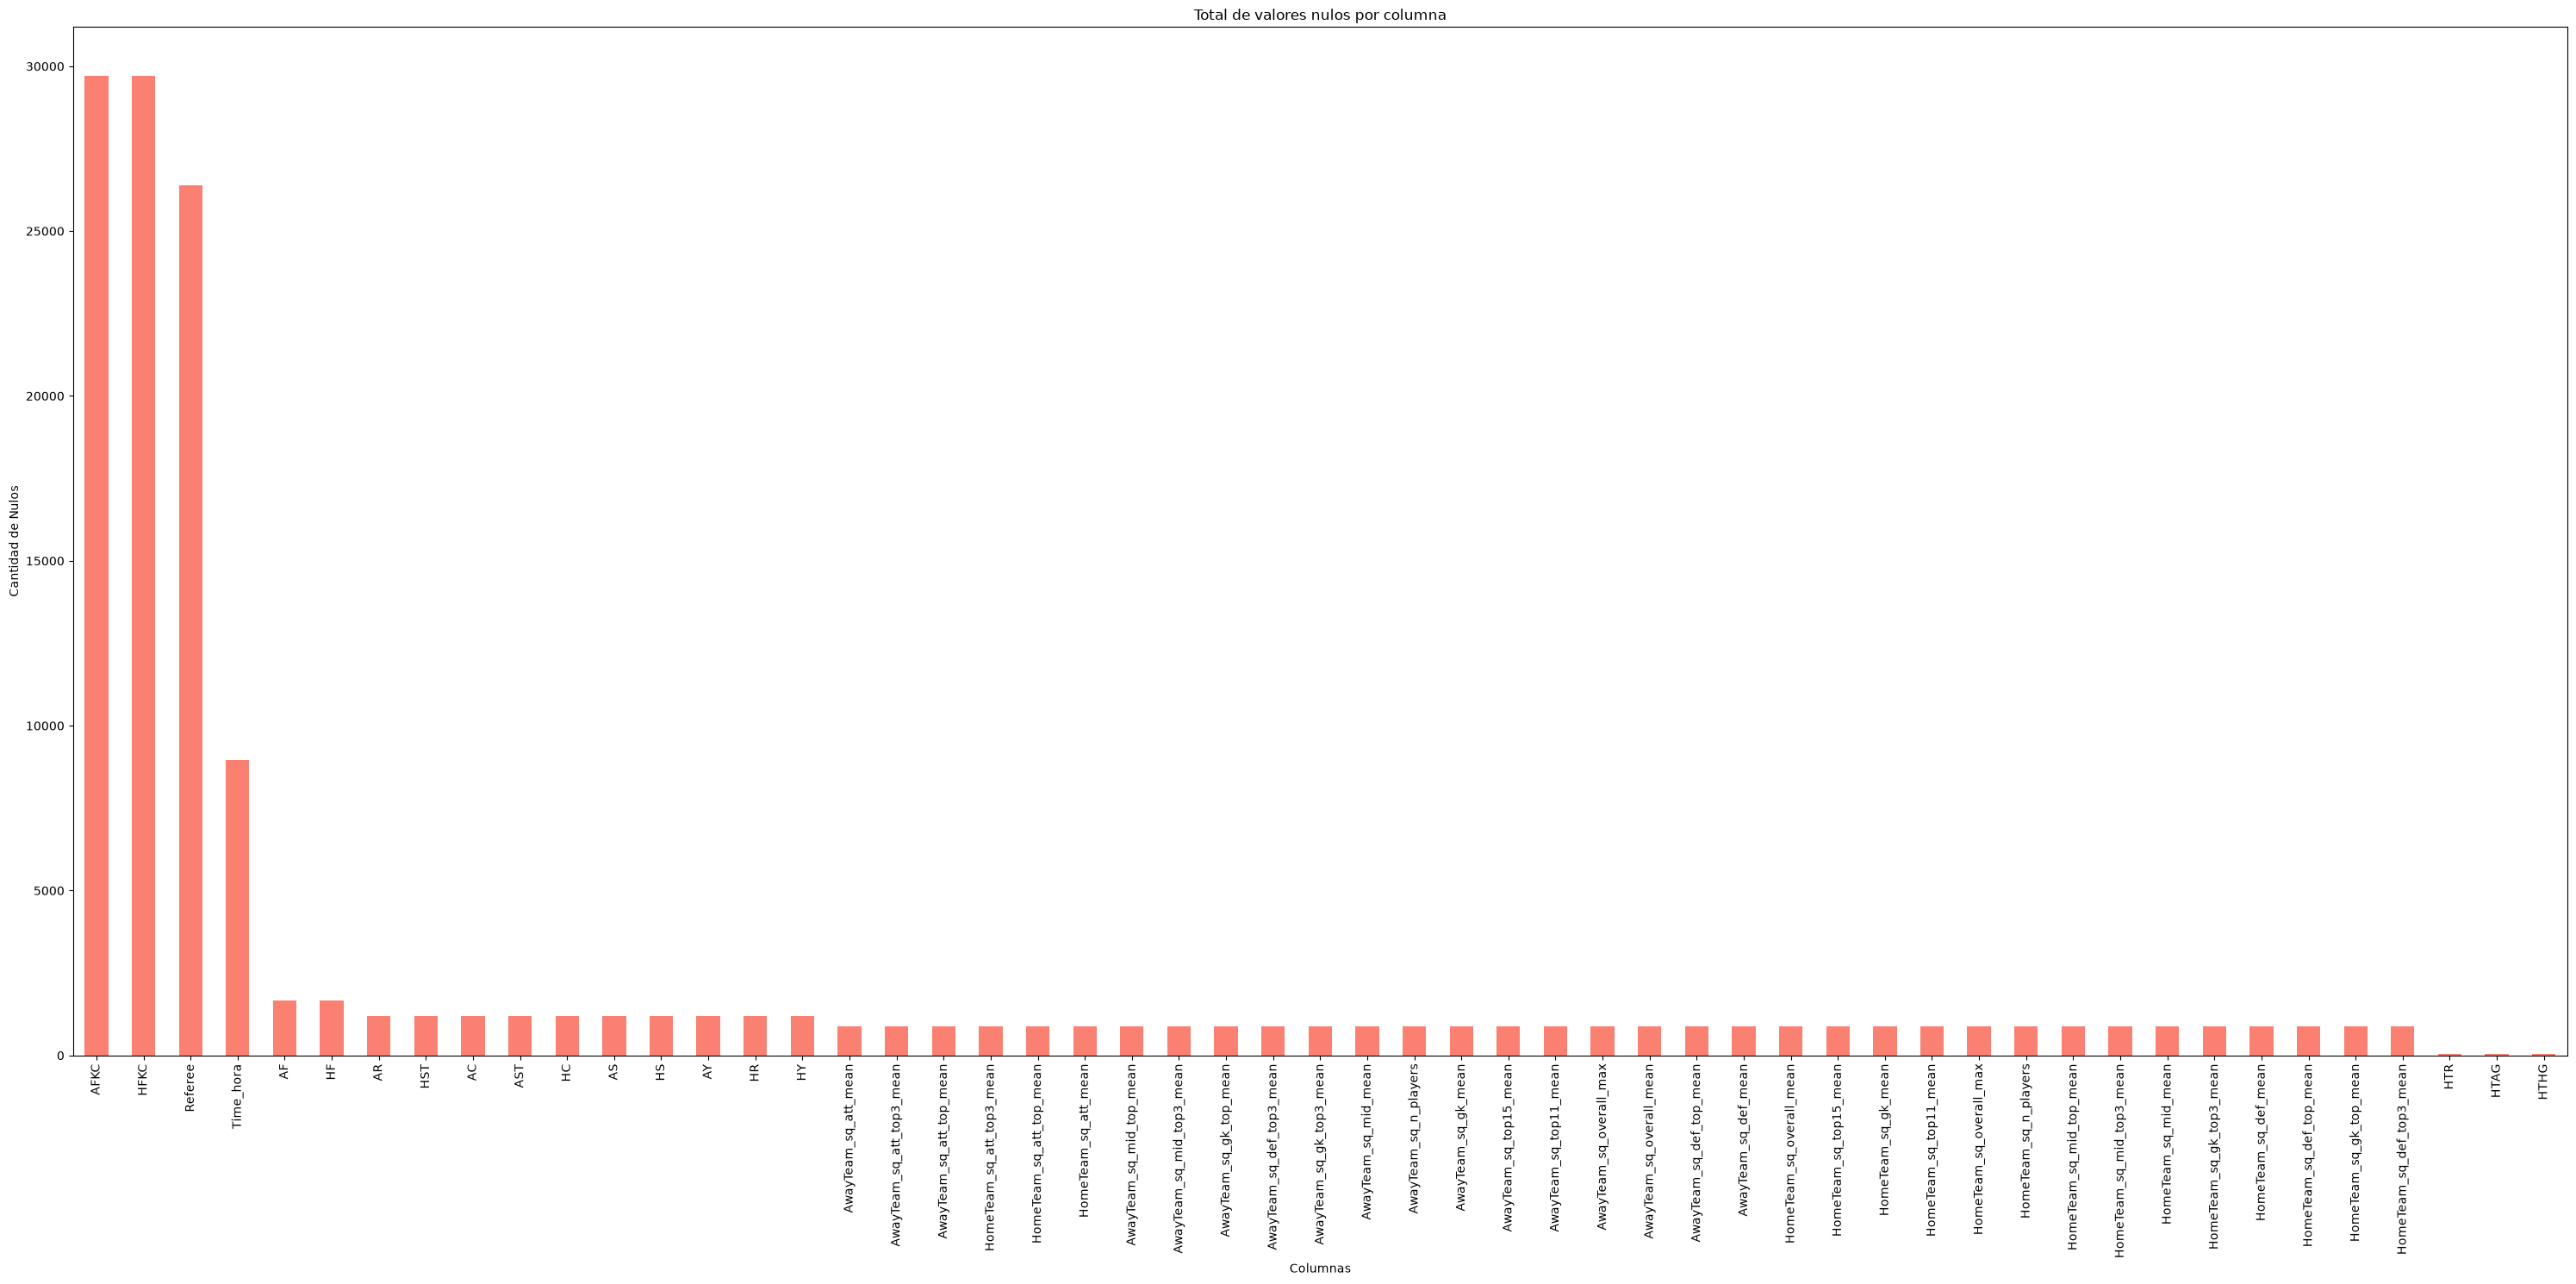

In [14]:
df_clean["Time_hora"] = pd.to_datetime(df_clean["Time"], format="%H:%M", errors="coerce").dt.hour
df_clean = df_clean.drop(columns=["Time"])
faltantes = []
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        faltantes.append(col)

col_faltantes = df_clean[faltantes].isnull().sum()

plt.figure(figsize=(30, 15))
col_faltantes.sort_values(ascending=False).plot(kind='bar', color='salmon')

plt.title('Total de valores nulos por columna')
plt.ylabel('Cantidad de Nulos')
plt.xlabel('Columnas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Como vemos tenemos a 3 variables (`HFKC`, `AFKC`, `Referee`) superon los 15k de nulos por lo que vamos a eliminar

In [15]:
df_clean = df_clean.drop(columns=['HFKC', 'AFKC', 'Referee'])
col_faltantes = col_faltantes.drop(['HFKC', 'AFKC', 'Referee'])

Y como observamos en la grafica anterior, vamos a imputar con `KNNImputer` para limpiar los datos faltantes de nuestro dataset

In [15]:
numericas = []
for col in col_faltantes.index:
    if df_clean[col].dtype in [np.float64, np.int64]:
        numericas.append(col)

scaler = StandardScaler()
df_clean[numericas] = scaler.fit_transform(df_clean[numericas])
imputer = KNNImputer(n_neighbors=5)
df_clean[numericas] = imputer.fit_transform(df_clean[numericas])
df_clean[numericas] = scaler.inverse_transform(df_clean[numericas])

In [16]:
columnas_con_nulos = df_clean.columns[df_clean.isnull().any()].tolist()
print(columnas_con_nulos)

['HTR', 'Referee']


Tenemos a la variable `HTR` (resultado al descanso) con algunos datos faltantes, entonces como es tipo string no podemos usar el `KNNImputer` la vamos a reconstruir con las variables de `HTHG`(total de goles local al medio tiempo) y `HTAG`(total de goles visitante  al medio tiempo)

In [17]:
m = df_clean["HTR"].isnull()
df_clean.loc[m, "HTR"] = np.select(
    [df_clean.loc[m, "HTHG"] > df_clean.loc[m, "HTAG"],
     df_clean.loc[m, "HTHG"] < df_clean.loc[m, "HTAG"]],
    ["H", "A"], default="D")
print("HTR nulos restantes:", df_clean["HTR"].isnull().sum())

HTR nulos restantes: 0


In [18]:
falta = df_clean.isnull().sum()
falta = falta[falta > 0]
print("Columnas con nulos tras toda la limpieza:", len(falta))

Columnas con nulos tras toda la limpieza: 1


## Exporte del dataset limpio

Guardamos `df_clean` (sin nulos, con banderas `*_Ausente` y `Time_hora`) como `matches_clean.csv`. `feature.ipynb` parte de este archivo limpio para el feature engineering.


In [19]:
df_clean.to_csv("../scripts/data/matches_clean.csv", index=False)


## Análisis Univariado

Antes de la creación de features exploramos **cada variable por separado**: resumimos los
estadísticos de todas las columnas numéricas y categóricas y visualizamos sus distribuciones
con histogramas. El objetivo es conocer rangos, sesgos y colas extremas.

Primero vamos a revisar el resumen estadístico de **todas las columnas numéricas**:
media, mediana, desviación estándar, cuartiles y valores mínimos/máximos. Esto permite detectar
rangos anómalos, sesgos y valores extremos legítimos por variable.

In [20]:
df_clean.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
FTHG,30182.0,1.56,1.31,0.00,1.00,1.00,2.00,10.00
FTAG,30182.0,1.25,1.18,0.00,0.00,1.00,2.00,13.00
HTHG,30182.0,0.69,0.84,0.00,0.00,0.00,1.00,6.00
HTAG,30182.0,0.55,0.76,0.00,0.00,0.00,1.00,7.00
HS,30182.0,13.50,5.28,-0.00,10.00,13.00,17.00,46.00
AS,30182.0,11.13,4.73,0.00,8.00,11.00,14.00,45.00
HST,30182.0,4.88,2.57,0.00,3.00,5.00,6.00,20.00
AST,30182.0,4.03,2.35,0.00,2.00,4.00,5.00,23.00
HF,30182.0,12.33,4.01,0.00,10.00,12.00,15.00,33.00
AF,30182.0,12.51,4.05,0.00,10.00,12.00,15.00,34.00


**Lo que se observa:**
- Los goles del local promedian 1.56 y los del visitante 1.25 (ventaja de localía aprox. 0.31 goles).
- Las cuotas tienen colas muy largas hacia arriba (p. ej. `PSCA` máx. 54.1 o `PSCH` máx. 48.6): son partidos muy
  desequilibrados, no errores.
- La squad quality tiene rangos acotados (`*_sq_overall_mean` entre 63 y 71), con outliers de élite
  en `*_sq_overall_max` (hasta 94).

Ahora revisamos las **variables categóricas**: la cardinalidad (cuántas categorías únicas
tiene cada una) y la frecuencia de los valores más repetidos, para detectar variables con demasiadas
o muy pocas categorías e inconsistencias de formato.

In [21]:
df_clean.describe(include="object")

/tmp/ipykernel_137984/592941607.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.describe(include="object")


,Div,Date,HomeTeam,AwayTeam,FTR,HTR,Referee
count,30182,30182,30182,30182,30182,30182,3800
unique,9,2152,280,280,3,3,50
top,E0,22/12/2018,Crystal Palace,Tottenham,H,D,A Taylor
freq,3800,53,190,190,13371,12143,295


In [22]:
vc_ftr = df_clean['FTR'].value_counts()
dist_frt = pd.DataFrame({'frecuencia': vc_ftr,'proporcion_pct': (vc_ftr / len(df_clean) * 100).round(1)}).loc[['H','D','A']]
dist_frt


,frecuencia,proporcion_pct
FTR,,
H,13371,44.3
D,7477,24.8
A,9334,30.9


**Lo que se observa:**
- 9 ligas, 10 temporadas, 280 equipos y 47 horarios de inicio distintos.
- `FTR` y `HTR` tienen 3 clases
- La variable objetivo está desbalanceada (H = 44.3%, A = 30.9%, D = 24.8%): se usará como
  *prior* del modelo, sin rebalancear.

Antes de graficar, vamos a **identificar las columnas numéricas binarias** (≤ 2 valores
únicos, típicamente 0/1): son banderas como `*_Ausente` (cuota no disponible) y `*_sq_mapped`.
No aportan a un histograma de distribución, por eso las separamos del resto.

In [25]:
num_univ = df_clean.select_dtypes(include=[np.number]).columns
binarias = [c for c in num_univ if df_clean[c].nunique() <= 2]
continuas = [c for c in num_univ if df_clean[c].nunique() > 2]
print(f"Numéricas totales: {len(num_univ)} | binarias (0/1): {len(binarias)} | continuas: {len(continuas)}")
binarias

Numéricas totales: 129 | binarias (0/1): 60 | continuas: 69


['HomeTeam_sq_mapped',
 'AwayTeam_sq_mapped',
 'IWH_Ausente',
 'IWD_Ausente',
 'IWA_Ausente',
 'VCH_Ausente',
 'VCD_Ausente',
 'VCA_Ausente',
 'MaxH_Ausente',
 'MaxD_Ausente',
 'MaxA_Ausente',
 'AvgH_Ausente',
 'AvgD_Ausente',
 'AvgA_Ausente',
 'B365>2.5_Ausente',
 'B365<2.5_Ausente',
 'P>2.5_Ausente',
 'P<2.5_Ausente',
 'Max>2.5_Ausente',
 'Max<2.5_Ausente',
 'Avg>2.5_Ausente',
 'Avg<2.5_Ausente',
 'AHh_Ausente',
 'B365AHH_Ausente',
 'B365AHA_Ausente',
 'PAHH_Ausente',
 'PAHA_Ausente',
 'MaxAHH_Ausente',
 'MaxAHA_Ausente',
 'AvgAHH_Ausente',
 'AvgAHA_Ausente',
 'B365CH_Ausente',
 'B365CD_Ausente',
 'B365CA_Ausente',
 'BWCH_Ausente',
 'BWCD_Ausente',
 'BWCA_Ausente',
 'MaxCH_Ausente',
 'MaxCD_Ausente',
 'MaxCA_Ausente',
 'AvgCH_Ausente',
 'AvgCD_Ausente',
 'AvgCA_Ausente',
 'B365C>2.5_Ausente',
 'B365C<2.5_Ausente',
 'PC>2.5_Ausente',
 'PC<2.5_Ausente',
 'MaxC>2.5_Ausente',
 'MaxC<2.5_Ausente',
 'AvgC>2.5_Ausente',
 'AvgC<2.5_Ausente',
 'AHCh_Ausente',
 'B365CAHH_Ausente',
 'B365CAHA_A

**Lo que se observa:** existen 60 banderas binarias formadas por los indicadores
`*_Ausente` (presencia/ausencia de cada cuota secundaria) y los flags `*_sq_mapped`. Se conservan
como features, pero se excluyen de los gráficos de distribución que siguen.

Ahora visualizamos la **distribución de todas las variables numéricas continuas** con
histogramas. Como son muchas, las agrupamos en figuras por bloques para que cada panel sea legible.

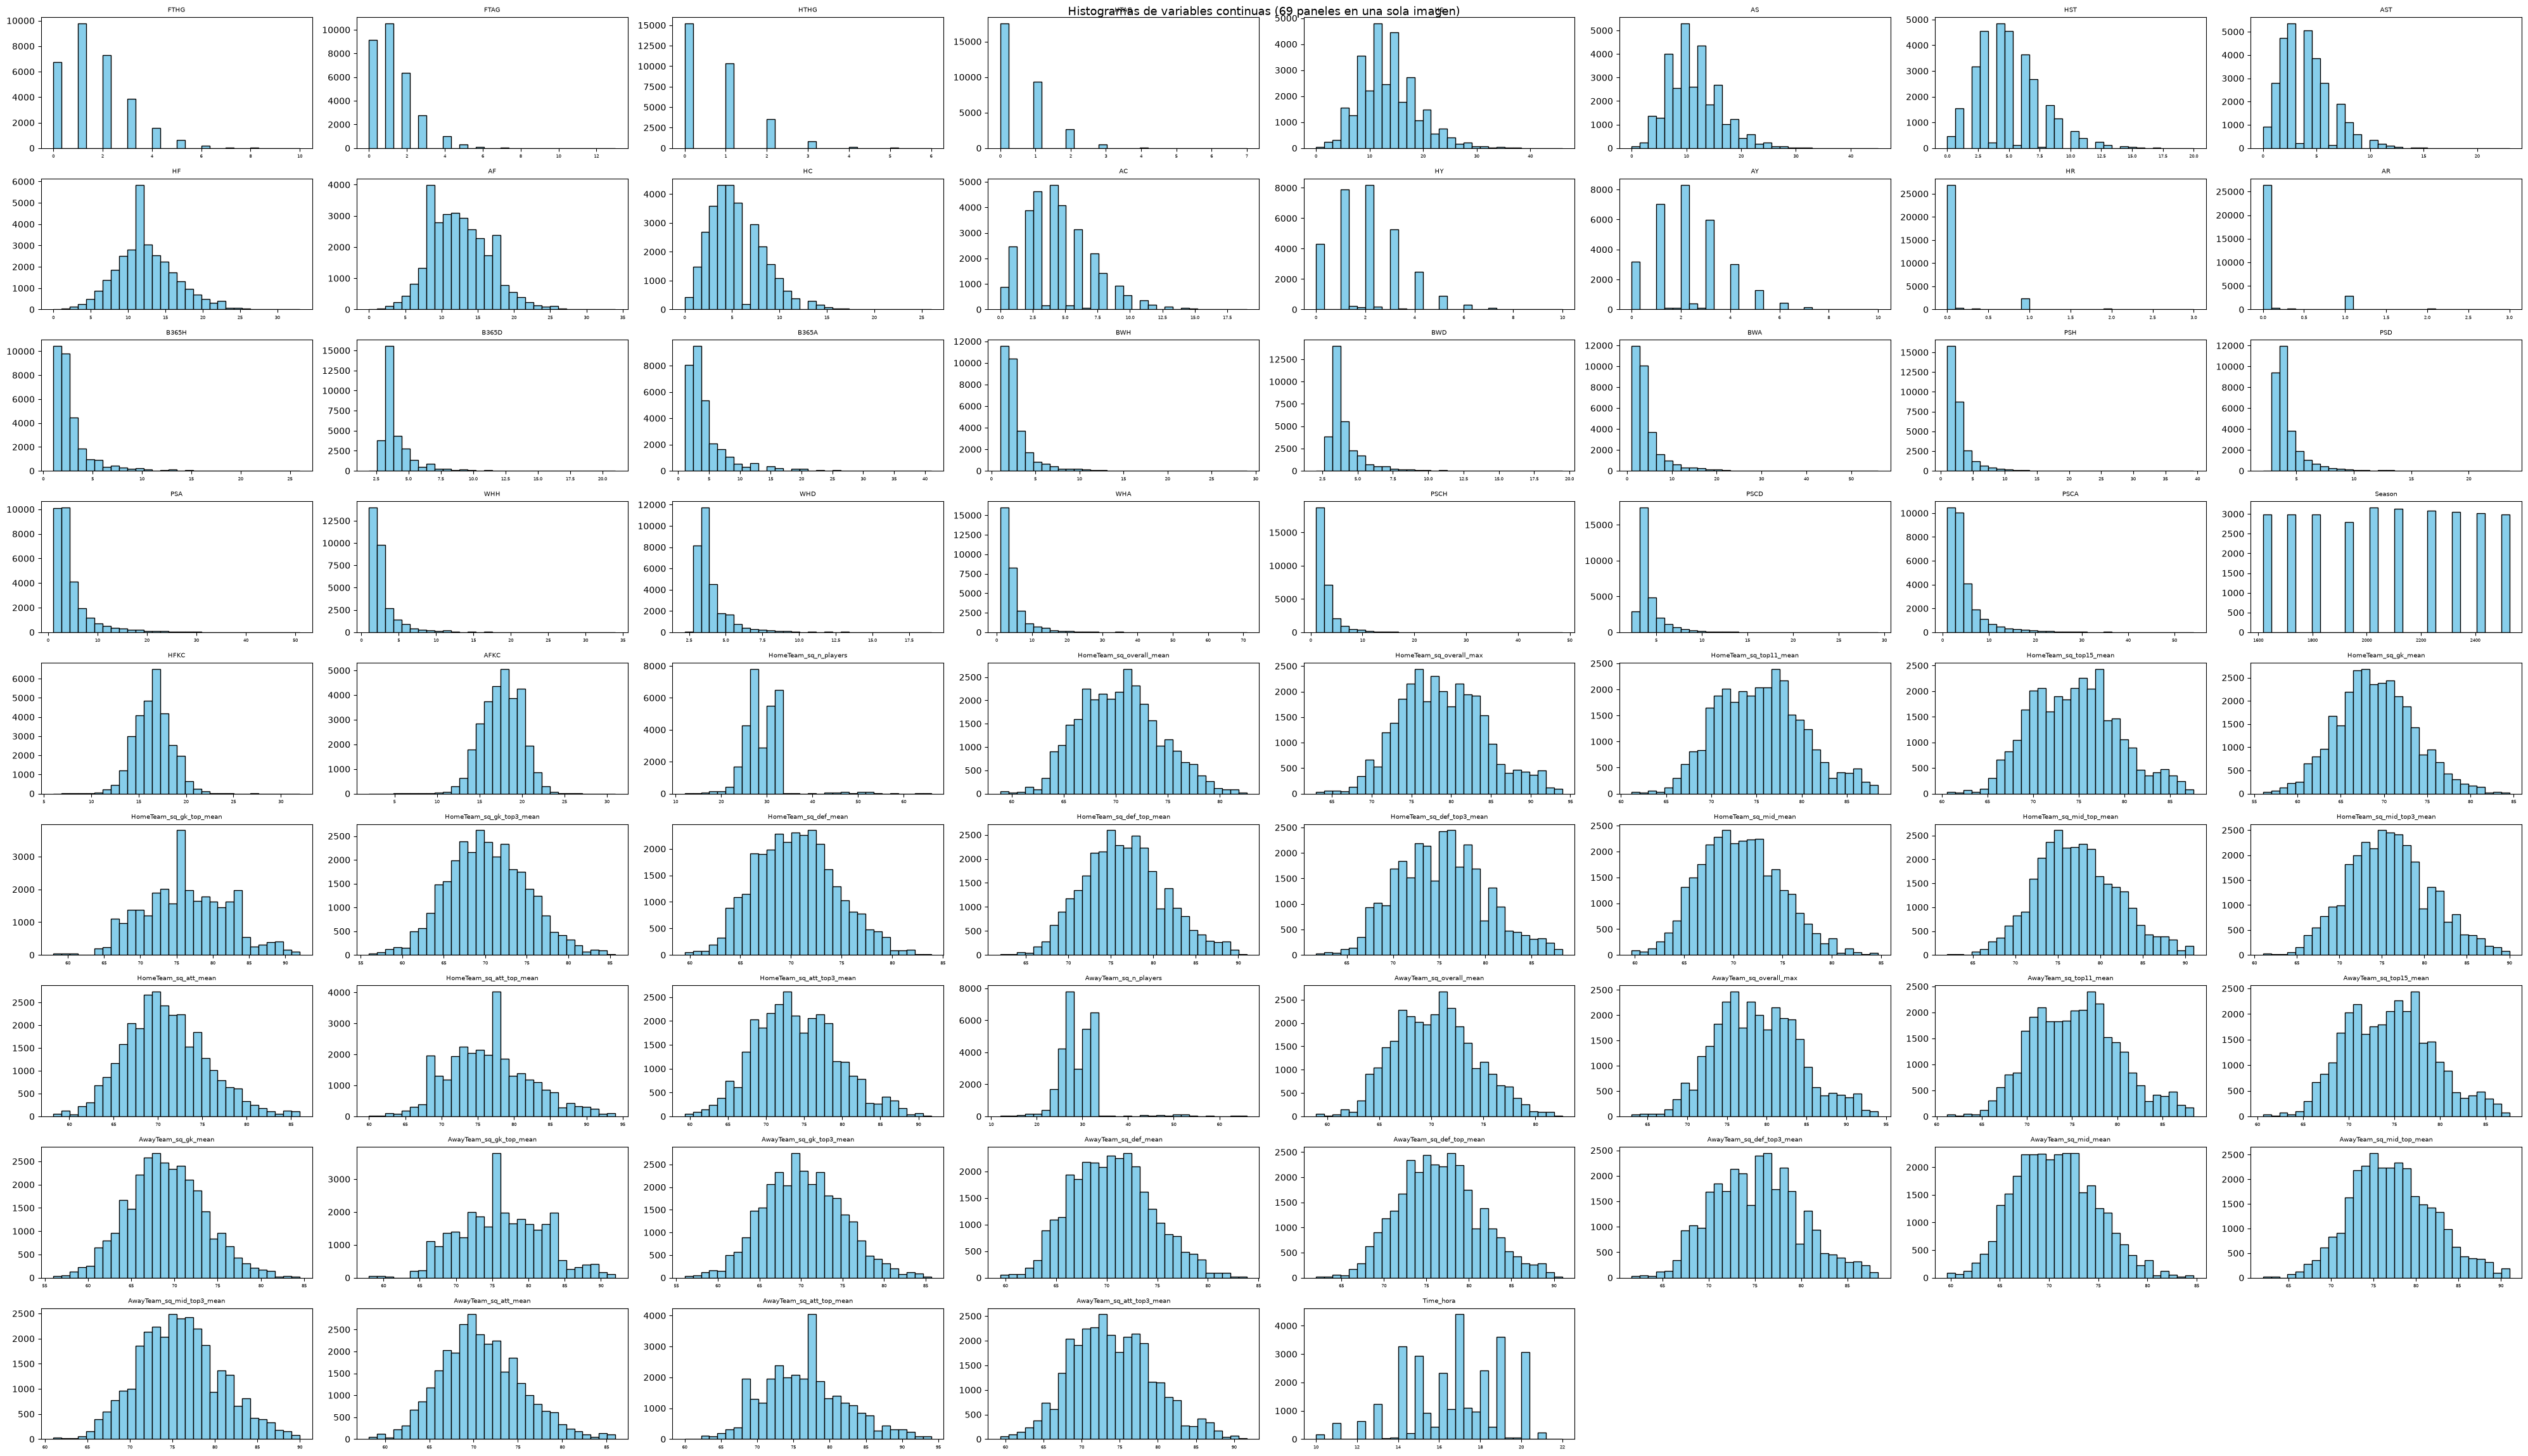

In [26]:
def graficar_hist(columnas, titulo, cols_por_fila=8, bins=30):
    n = len(columnas)
    if n == 0:
        print('Sin columnas para graficar:', titulo)
        return
    filas = int(np.ceil(n / cols_por_fila))
    fig, axes = plt.subplots(filas, cols_por_fila, figsize=(5 * cols_por_fila, 2.6 * filas))
    axes = np.atleast_2d(axes)
    for ax, c in zip(axes.ravel(), columnas):
        s = df_clean[c].dropna()
        ax.hist(s, bins=bins, color='skyblue', edgecolor='black')
        ax.set_title(c, fontsize=7)
        ax.tick_params(axis='x', labelsize=5)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

# Una sola imagen con TODAS las variables continuas (se hace scroll en el notebook)
bloques_cont = [continuas]
graficar_hist(continuas, f'Histogramas de variables continuas ({len(continuas)} paneles en una sola imagen)')


**Lo que se observa:**
- Goles, tiros, faltas y tarjetas tienen **sesgo positivo** (cola hacia la derecha) con máximos
  legítimos (p. ej. 13 goles del visitante).
- Las cuotas de cierre 1X2 de Pinnacle (`PSCH`/`PSCD`/`PSCA`) están sesgadas con el pico en cuotas
  bajas: la masa de partidos son favoritos claros.
- El rango intercuartil de las continuas es el esperado en fútbol; nada indica errores de medición.

Para completar el univariado, visualizamos las **variables binarias** con barras de
frecuencia, confirmando que son flags 0/1 puros (presencia/ausencia).

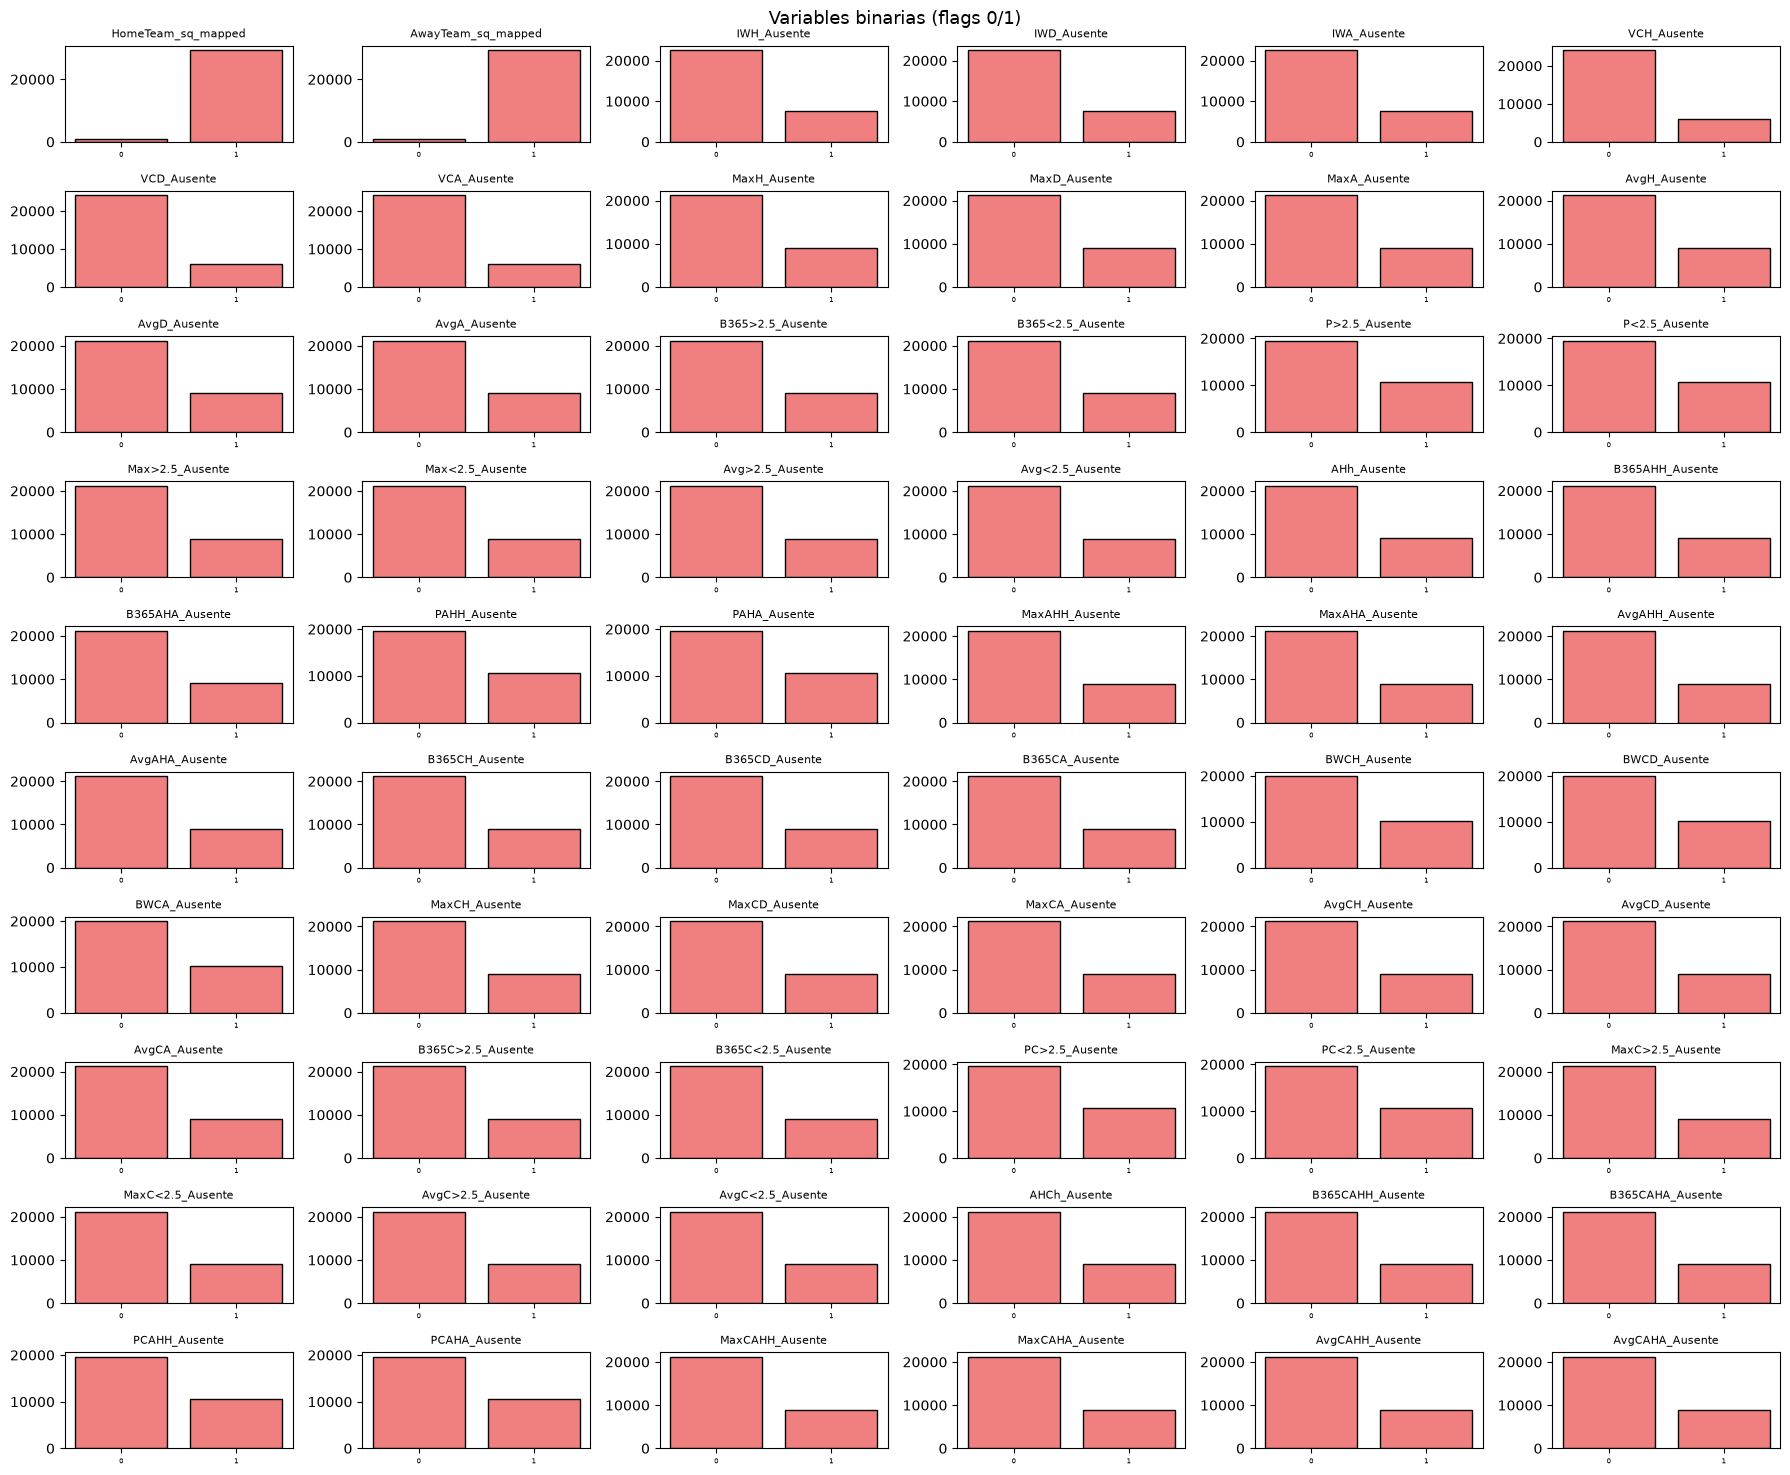

In [27]:
def graficar_binarias(columnas, cols_por_fila=6, figsize=(18, 15)):
    n = len(columnas)
    if n == 0:
        return
    filas = int(np.ceil(n / cols_por_fila))
    fig, axes = plt.subplots(filas, cols_por_fila, figsize=figsize)
    axes = np.atleast_2d(axes)
    for ax, c in zip(axes.ravel(), columnas):
        vc = df_clean[c].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color='lightcoral', edgecolor='black')
        ax.set_title(c, fontsize=8)
        ax.tick_params(axis='x', labelsize=5)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.suptitle('Variables binarias (flags 0/1)', fontsize=13)
    plt.tight_layout()
    plt.show()

graficar_binarias(binarias)

**Lo que se observa:** son flags 0/1 puros: `*_Ausente` indica si la cuota estuvo
disponible (la ausencia del mercado es informativa) y `*_sq_mapped` si el equipo tenía snapshot de
squad. Se conservan como features, no se eliminan.

Vamos a verificar si existen **filas duplicadas** (el mismo partido cargado dos veces),
que inflarían el dataset y duplicarían información durante el entrenamiento.

In [28]:
print("exact duplicate rows:", df_clean.duplicated().sum())
df_clean[df_clean.duplicated(keep=False)].sort_values(list(df_clean.columns)).head(6)

exact duplicate rows: 0


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,PSH,PSD,PSA,WHH,WHD,WHA,PSCH,PSCD,PSCA,Season,HFKC,AFKC,HomeTeam_sq_n_players,HomeTeam_sq_overall_mean,HomeTeam_sq_overall_max,HomeTeam_sq_top11_mean,HomeTeam_sq_top15_mean,HomeTeam_sq_gk_mean,HomeTeam_sq_gk_top_mean,HomeTeam_sq_gk_top3_mean,HomeTeam_sq_def_mean,HomeTeam_sq_def_top_mean,HomeTeam_sq_def_top3_mean,HomeTeam_sq_mid_mean,HomeTeam_sq_mid_top_mean,HomeTeam_sq_mid_top3_mean,HomeTeam_sq_att_mean,HomeTeam_sq_att_top_mean,HomeTeam_sq_att_top3_mean,HomeTeam_sq_mapped,AwayTeam_sq_n_players,AwayTeam_sq_overall_mean,AwayTeam_sq_overall_max,AwayTeam_sq_top11_mean,AwayTeam_sq_top15_mean,AwayTeam_sq_gk_mean,AwayTeam_sq_gk_top_mean,AwayTeam_sq_gk_top3_mean,AwayTeam_sq_def_mean,AwayTeam_sq_def_top_mean,AwayTeam_sq_def_top3_mean,AwayTeam_sq_mid_mean,AwayTeam_sq_mid_top_mean,AwayTeam_sq_mid_top3_mean,AwayTeam_sq_att_mean,AwayTeam_sq_att_top_mean,AwayTeam_sq_att_top3_mean,AwayTeam_sq_mapped,IWH_Ausente,IWD_Ausente,IWA_Ausente,VCH_Ausente,VCD_Ausente,VCA_Ausente,MaxH_Ausente,MaxD_Ausente,MaxA_Ausente,AvgH_Ausente,AvgD_Ausente,AvgA_Ausente,B365>2.5_Ausente,B365<2.5_Ausente,P>2.5_Ausente,P<2.5_Ausente,Max>2.5_Ausente,Max<2.5_Ausente,Avg>2.5_Ausente,Avg<2.5_Ausente,AHh_Ausente,B365AHH_Ausente,B365AHA_Ausente,PAHH_Ausente,PAHA_Ausente,MaxAHH_Ausente,MaxAHA_Ausente,AvgAHH_Ausente,AvgAHA_Ausente,B365CH_Ausente,B365CD_Ausente,B365CA_Ausente,BWCH_Ausente,BWCD_Ausente,BWCA_Ausente,MaxCH_Ausente,MaxCD_Ausente,MaxCA_Ausente,AvgCH_Ausente,AvgCD_Ausente,AvgCA_Ausente,B365C>2.5_Ausente,B365C<2.5_Ausente,PC>2.5_Ausente,PC<2.5_Ausente,MaxC>2.5_Ausente,MaxC<2.5_Ausente,AvgC>2.5_Ausente,AvgC<2.5_Ausente,AHCh_Ausente,B365CAHH_Ausente,B365CAHA_Ausente,PCAHH_Ausente,PCAHA_Ausente,MaxCAHH_Ausente,MaxCAHA_Ausente,AvgCAHH_Ausente,AvgCAHA_Ausente,Time_hora


**Lo que se observa:** no hay duplicados exactos. La clave compuesta
`(Div, Season, Date, HomeTeam, AwayTeam)` identifica cada partido de forma única, así que no es
necesario deduplicar.

## Outliers: detectar y luego decidir

Usamos la **regla del IQR**: un valor es outlier si queda fuera de $[Q_1 - 1.5\cdot\text{IQR},\; Q_3 + 1.5\cdot\text{IQR}]$. Sabemos que **no todo extremo es un error**, así que primero detectamos con boxplots e histogramas (con las vallas IQR dibujadas) y recién después decidimos qué hacer con ellos.

Vamos a graficar los **boxplots de todas las variables continuas** (en bloques). Cada
punto fuera del boxplot es un outlier por la regla del IQR; en el título mostramos cuántos valores fueron flaggeados.

/tmp/ipykernel_137984/184735253.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/184735253.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/184735253.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/184735253.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/184735253.py:1

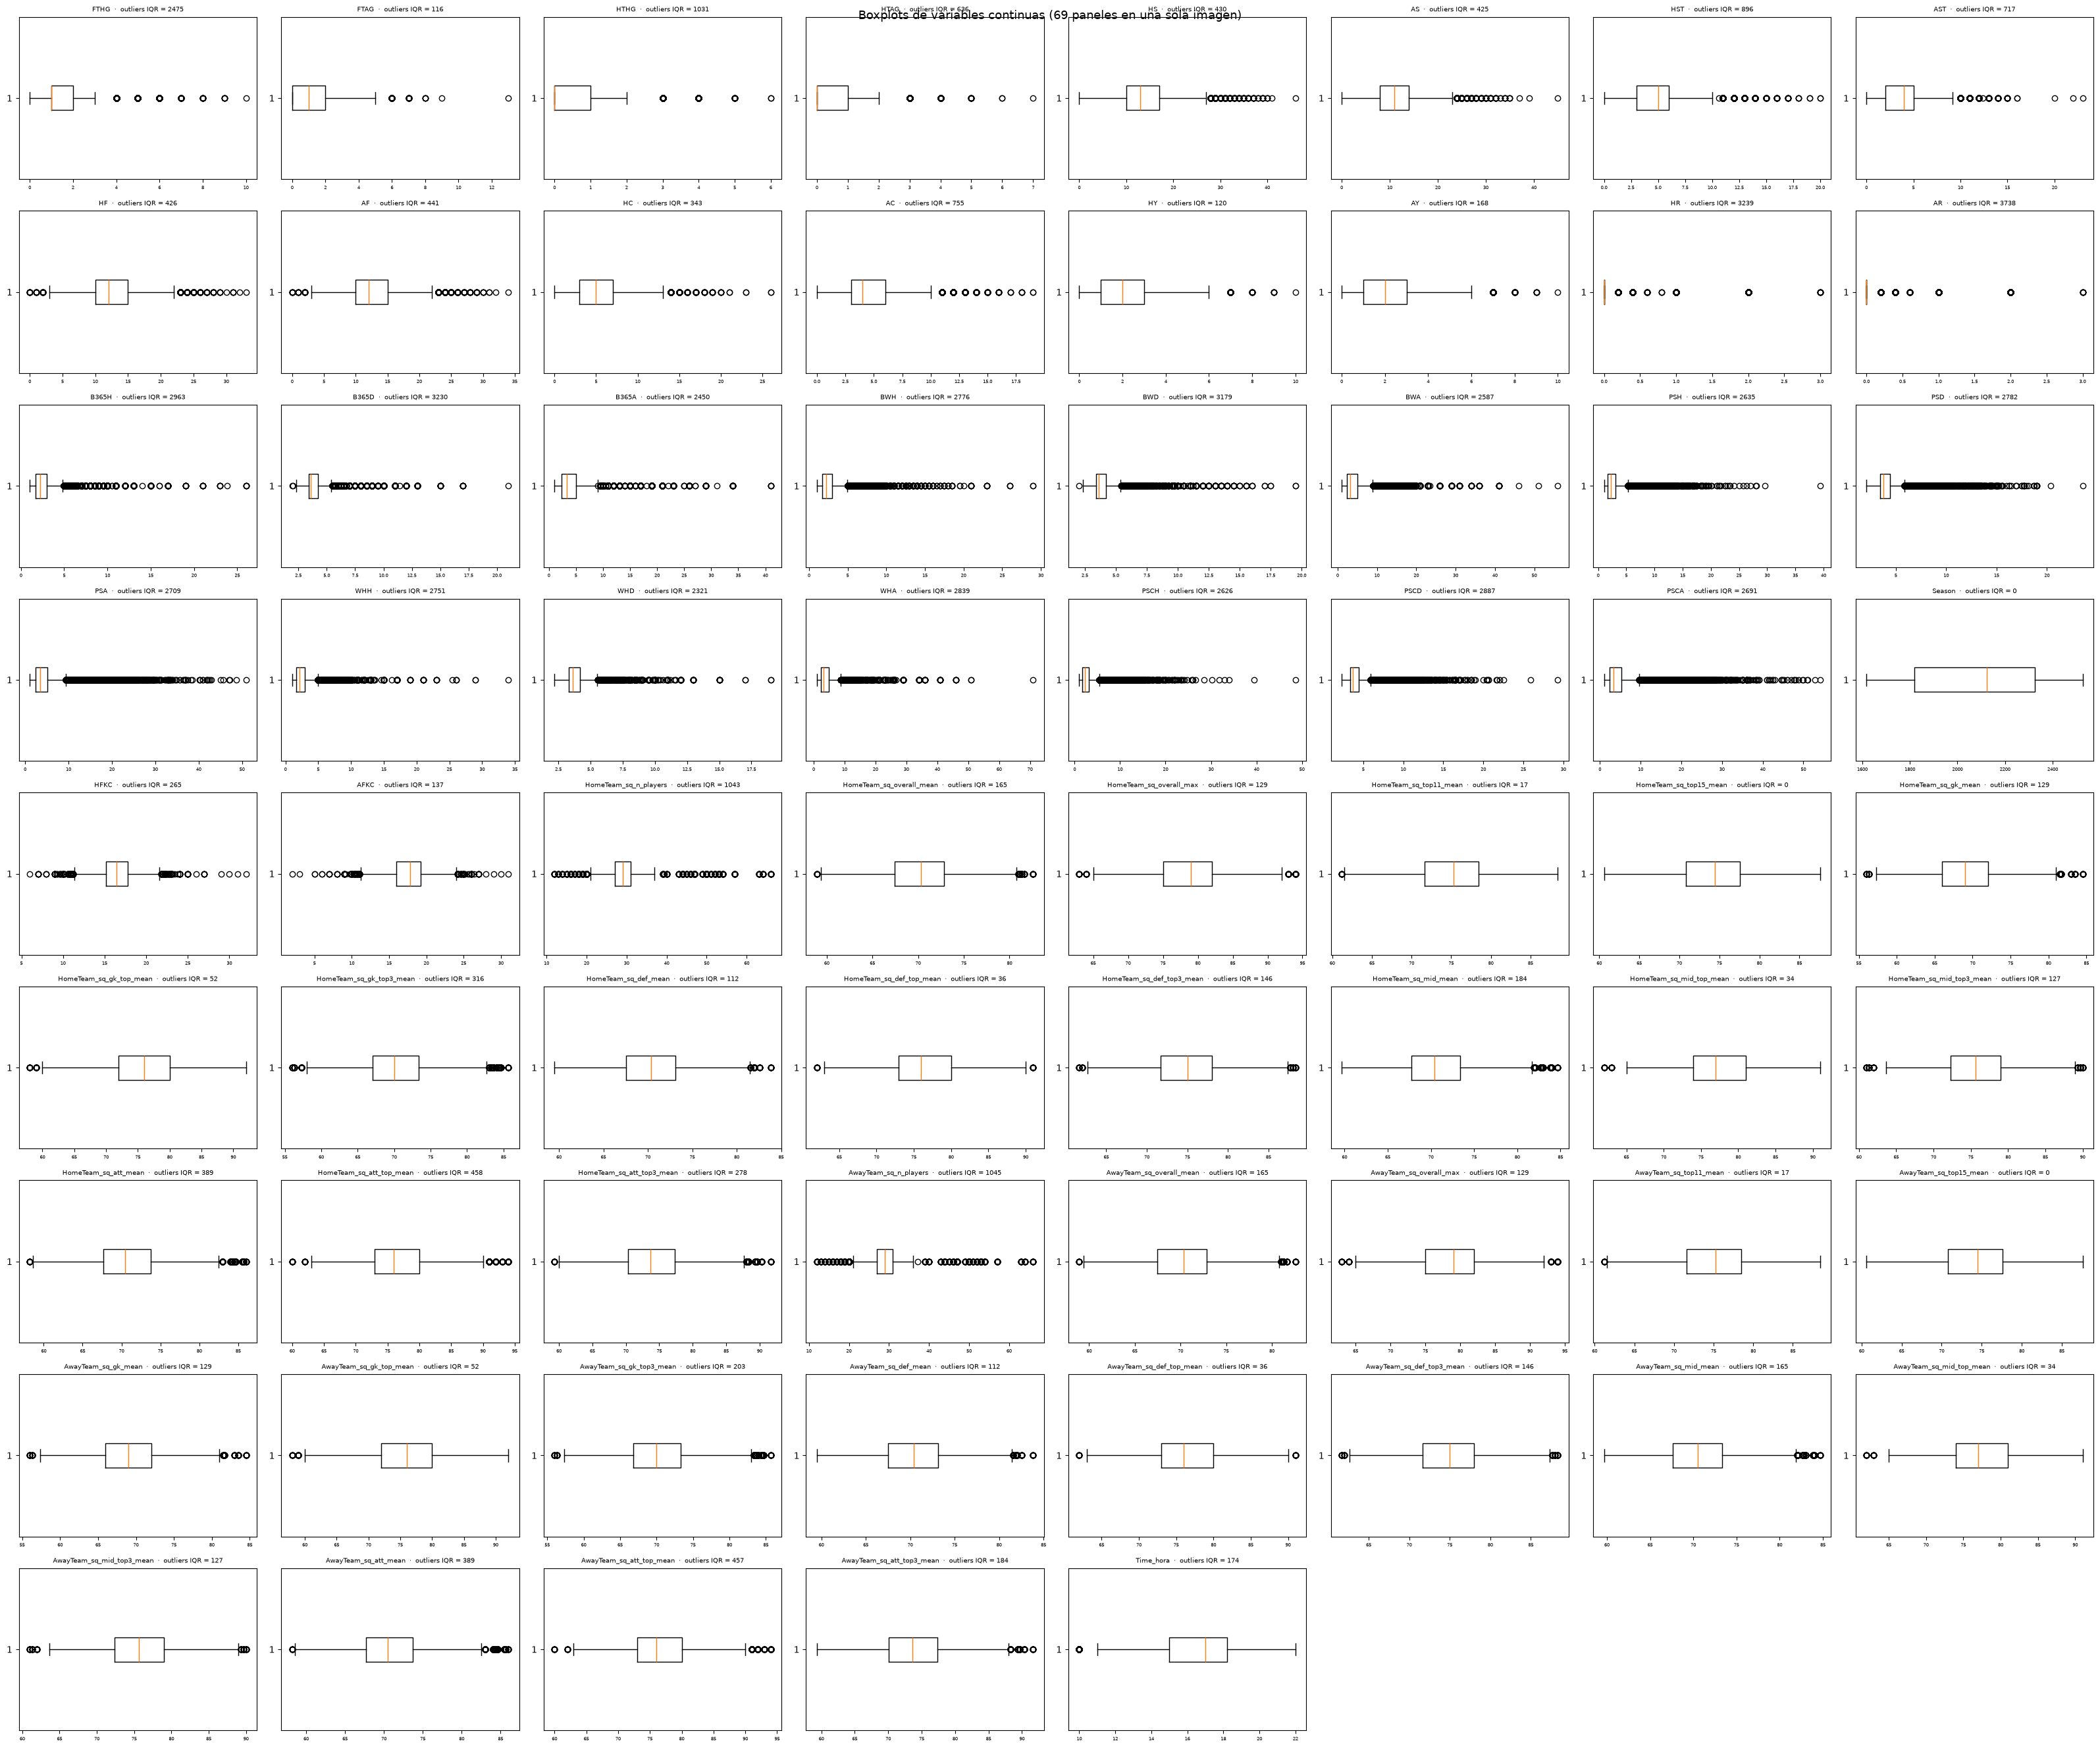

In [29]:
def iqr_fences(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

def graficar_boxplots(columnas, titulo, cols_por_fila=8):
    n = len(columnas)
    if n == 0:
        return
    filas = int(np.ceil(n / cols_por_fila))
    fig, axes = plt.subplots(filas, cols_por_fila, figsize=(4 * cols_por_fila, 3* filas))
    axes = np.atleast_2d(axes)
    for ax, c in zip(axes.ravel(), columnas):
        s = df_clean[c].dropna()
        lo, hi = iqr_fences(s)
        nout = int(((s < lo) | (s > hi)).sum())
        ax.boxplot(s, vert=False, showfliers=True)
        ax.set_title(f"{c}  ·  outliers IQR = {nout}", fontsize=7)
        ax.tick_params(axis='x', labelsize=5)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

graficar_boxplots(continuas, f'Boxplots de variables continuas ({len(continuas)} paneles en una sola imagen)')


**Lo que se observa:** en las variables de goles, tiros, faltas y tarjetas los puntos
extremos son pocos (<2%) y corresponden a partidos reales atípicos. En las cuotas los "outliers"
son partidos muy desequilibrados (favoritos claros), no errores de medición.

Ahora los **histogramas de las mismas variables con las vallas IQR dibujadas** (líneas
rojas discontinuas) y el rango `[lo, hi]` en el título: ubican visualmente dónde empiezan los
outliers en cada variable.

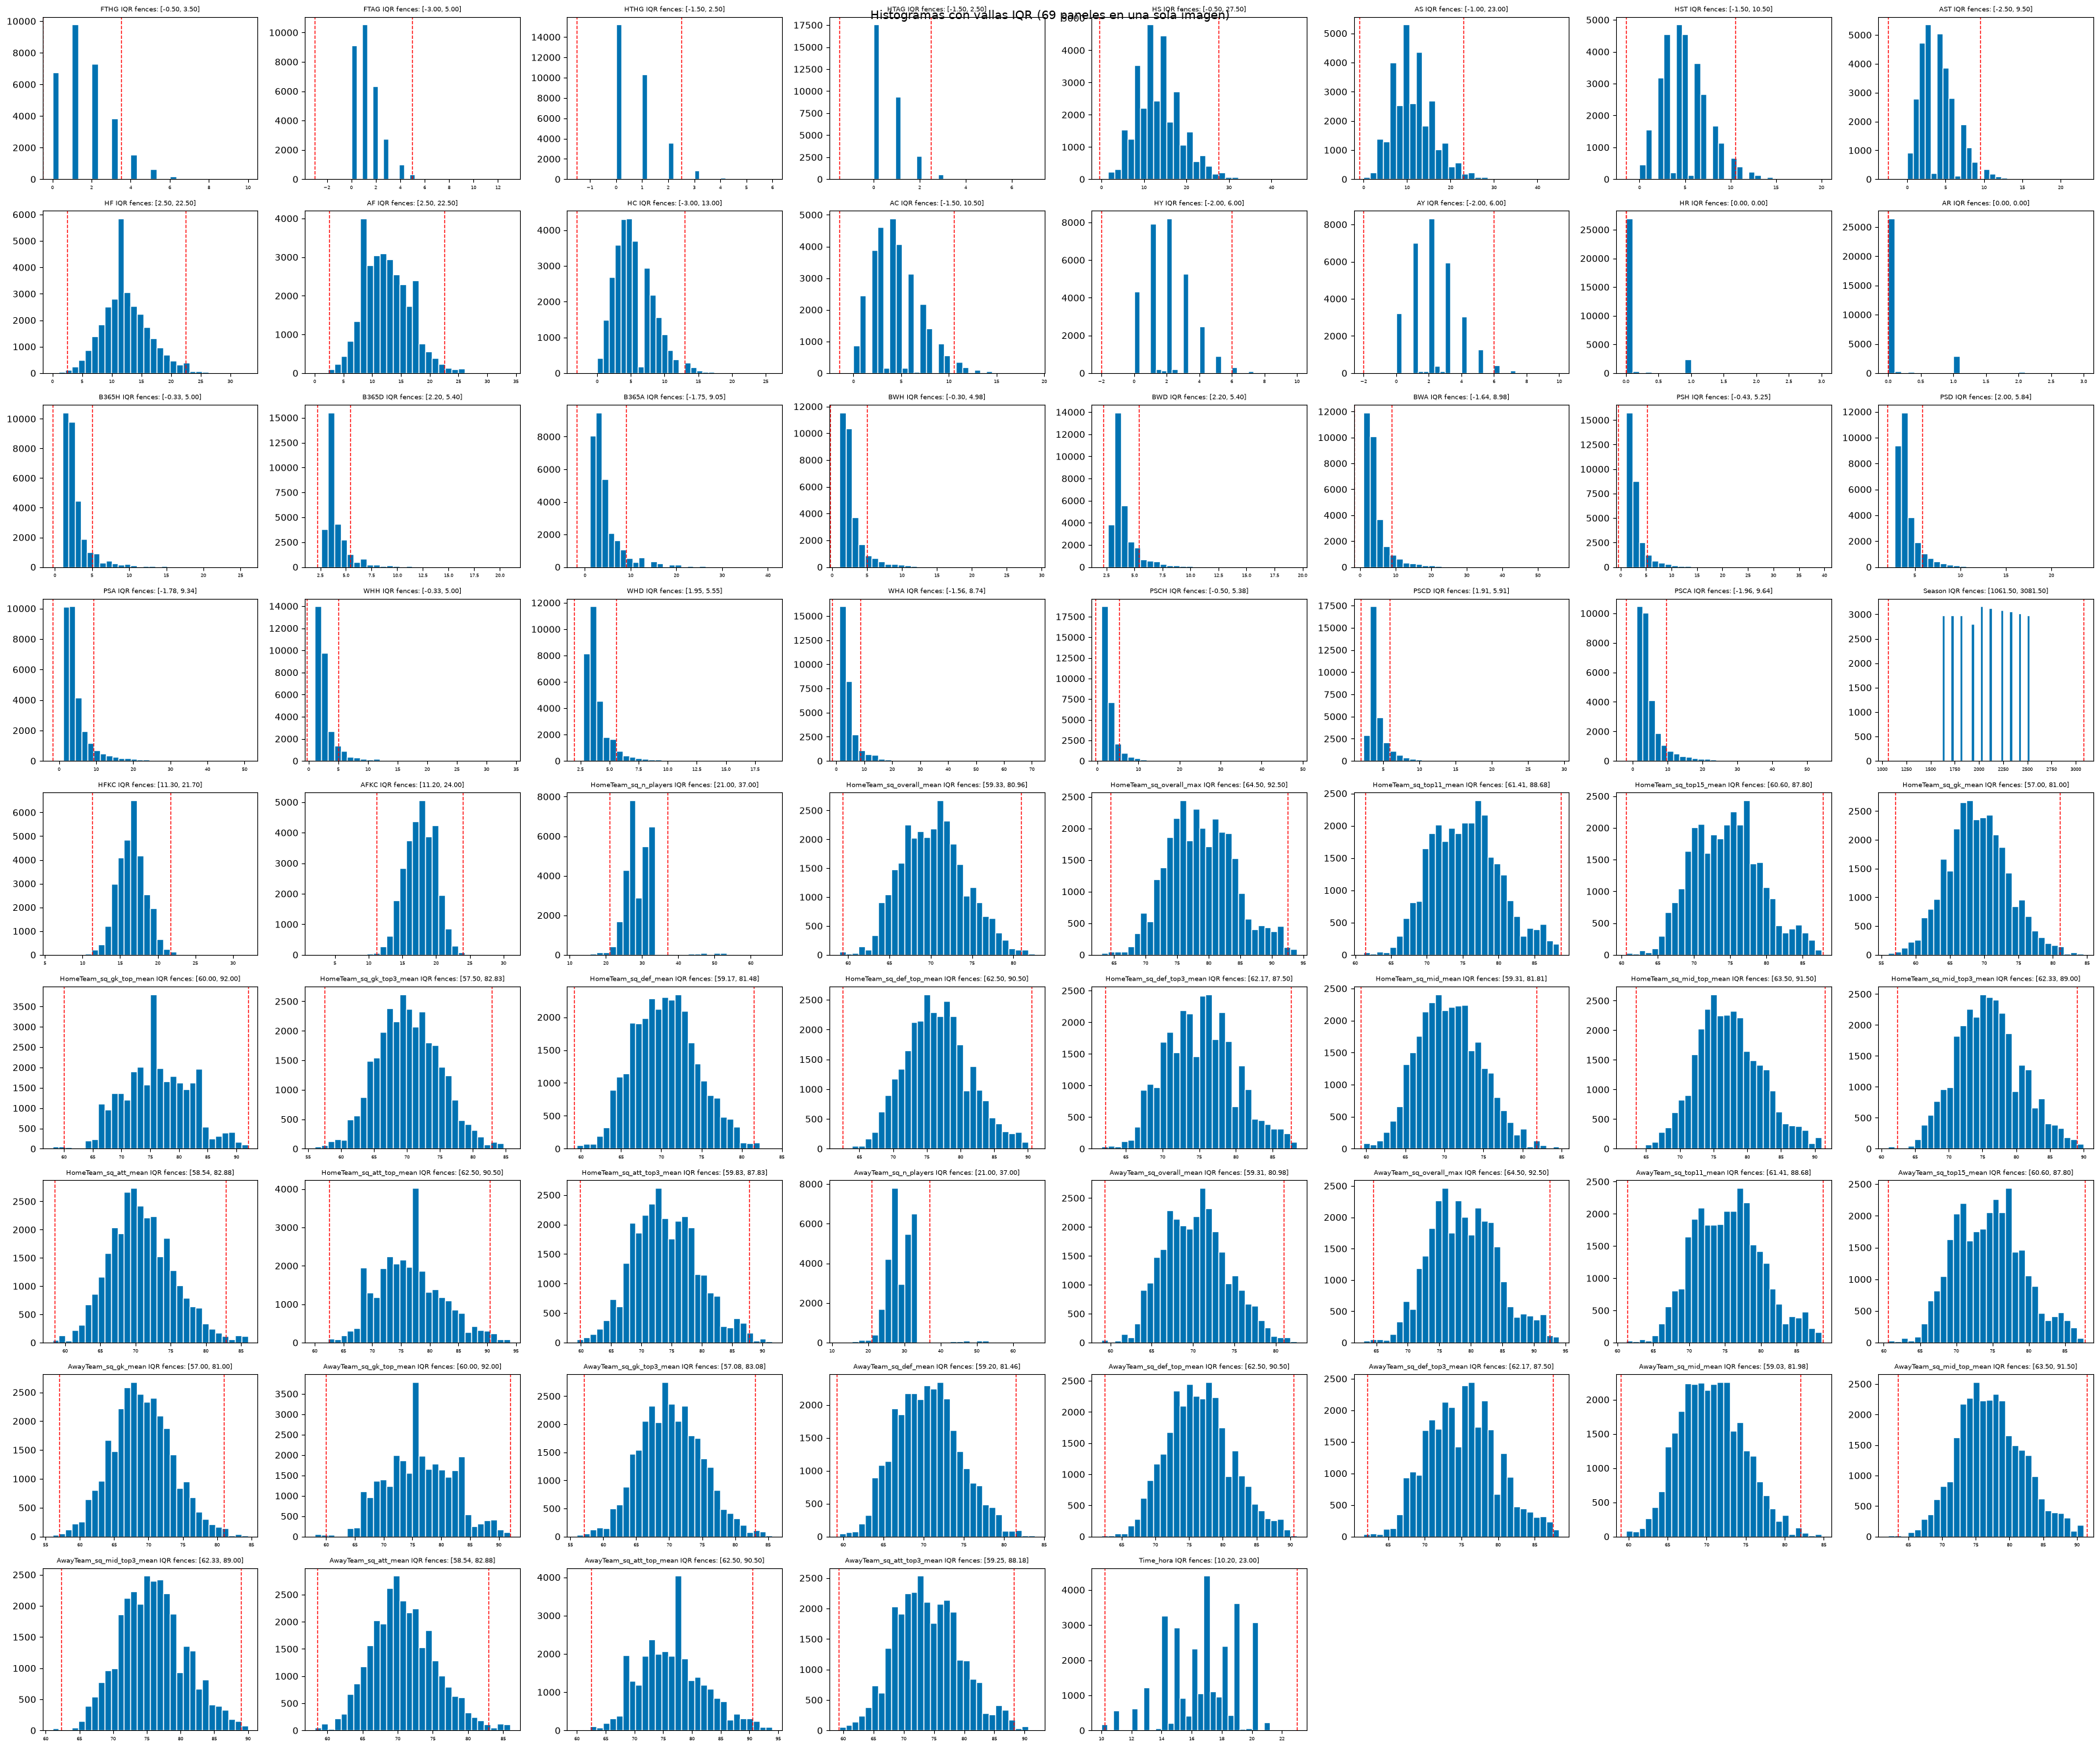

In [30]:
def graficar_hist_iqr(columnas, titulo, cols_por_fila=8, bins=30):
    n = len(columnas)
    if n == 0:
        return
    filas = int(np.ceil(n / cols_por_fila))
    fig, axes = plt.subplots(filas, cols_por_fila, figsize=(4 * cols_por_fila, 3 * filas))
    axes = np.atleast_2d(axes)
    for ax, c in zip(axes.ravel(), columnas):
        s = df_clean[c].dropna()
        lo, hi = iqr_fences(s)
        ax.hist(s, bins=bins, color='#0072B2', edgecolor='white')
        ax.axvline(lo, color='red', ls='--', lw=1)
        ax.axvline(hi, color='red', ls='--', lw=1)
        ax.set_title(f"{c} IQR fences: [{lo:.2f}, {hi:.2f}]", fontsize=7)
        ax.tick_params(axis='x', labelsize=5)
    for ax in axes.ravel()[n:]:
        ax.axis('off')
    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

graficar_hist_iqr(continuas, f'Histogramas con vallas IQR ({len(continuas)} paneles en una sola imagen)')


**Lo que se observa:** confirmamos la ubicación de las colas: para goles/tiros el
extremo superior queda muy por encima de `hi` (pocos partidos rarísimos) y para las cuotas la cola
alta refleja los long-shots del mercado. Ningún valor parece un error de captura.

Como las figuras anteriores son muy extensas, hacemos un **gráfico resumen con las
variables más representativas** del proyecto: goles (`FTHG`, `FTAG`), tiros (`HS`, `AS`), cuota
media de mercado (`AvgH`, `AvgD`, `AvgA`) y squad quality (`*_sq_top11_mean`), combinando boxplot
e histograma con vallas IQR por variable.

La media de mercado (`Avg`) es la representación del mercado 1X2 que conserva el pipeline de
features: es prácticamente equivalente a las cuotas de cierre de Pinnacle (el acierto del favorito
difiere en menos de 1 pp, 53.9% vs 54.5%) pero tiene mayor cobertura de datos. Las `Avg` no superan
el filtro de faltantes de `df_clean` (29.8% de nulos), por eso en las figuras se leen desde el
dataset crudo `df`.

/tmp/ipykernel_137984/199077421.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/199077421.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/199077421.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/199077421.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(s, vert=False, showfliers=True)
/tmp/ipykernel_137984/199077421.py:1

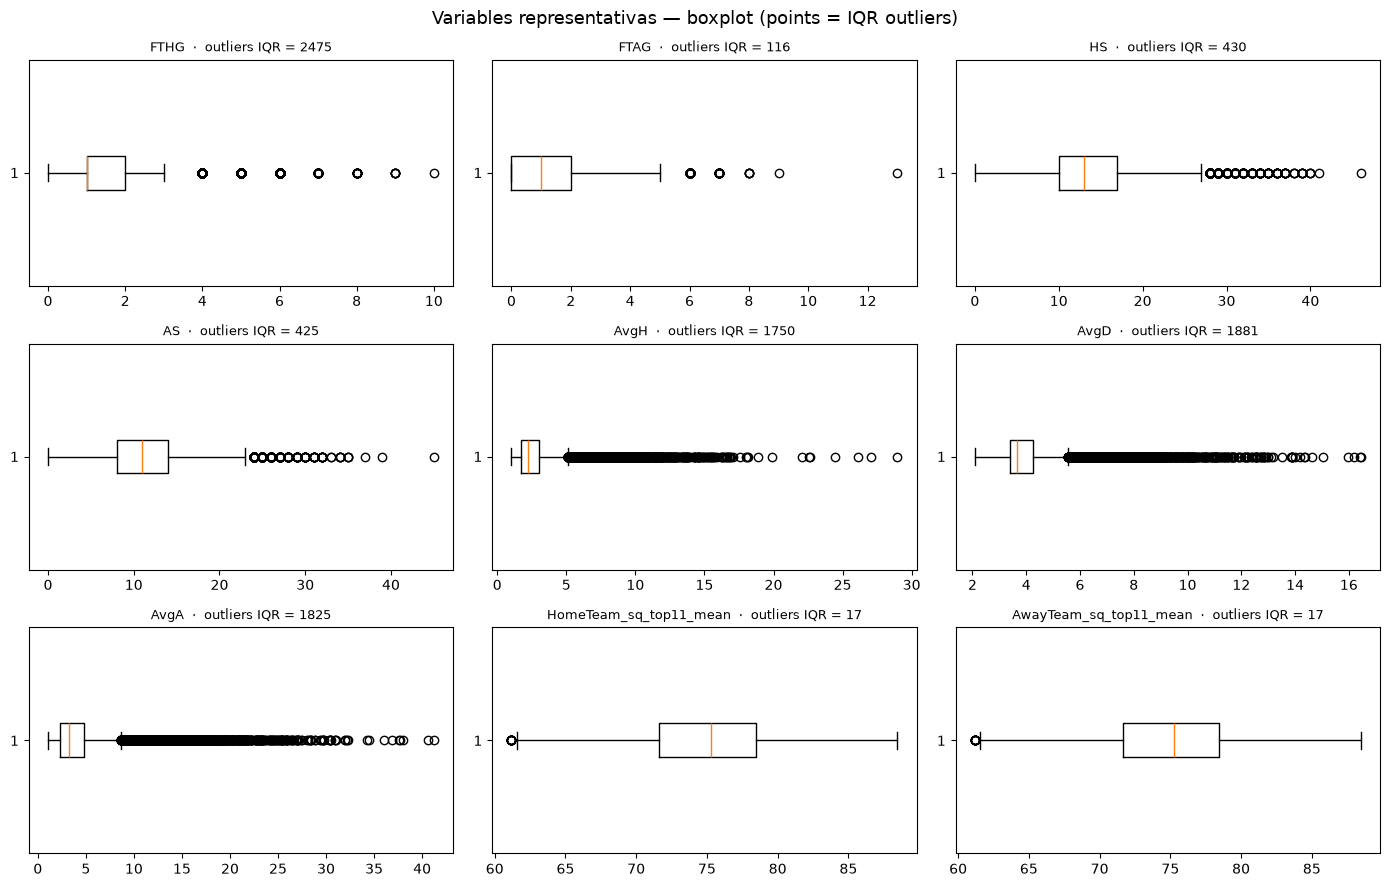

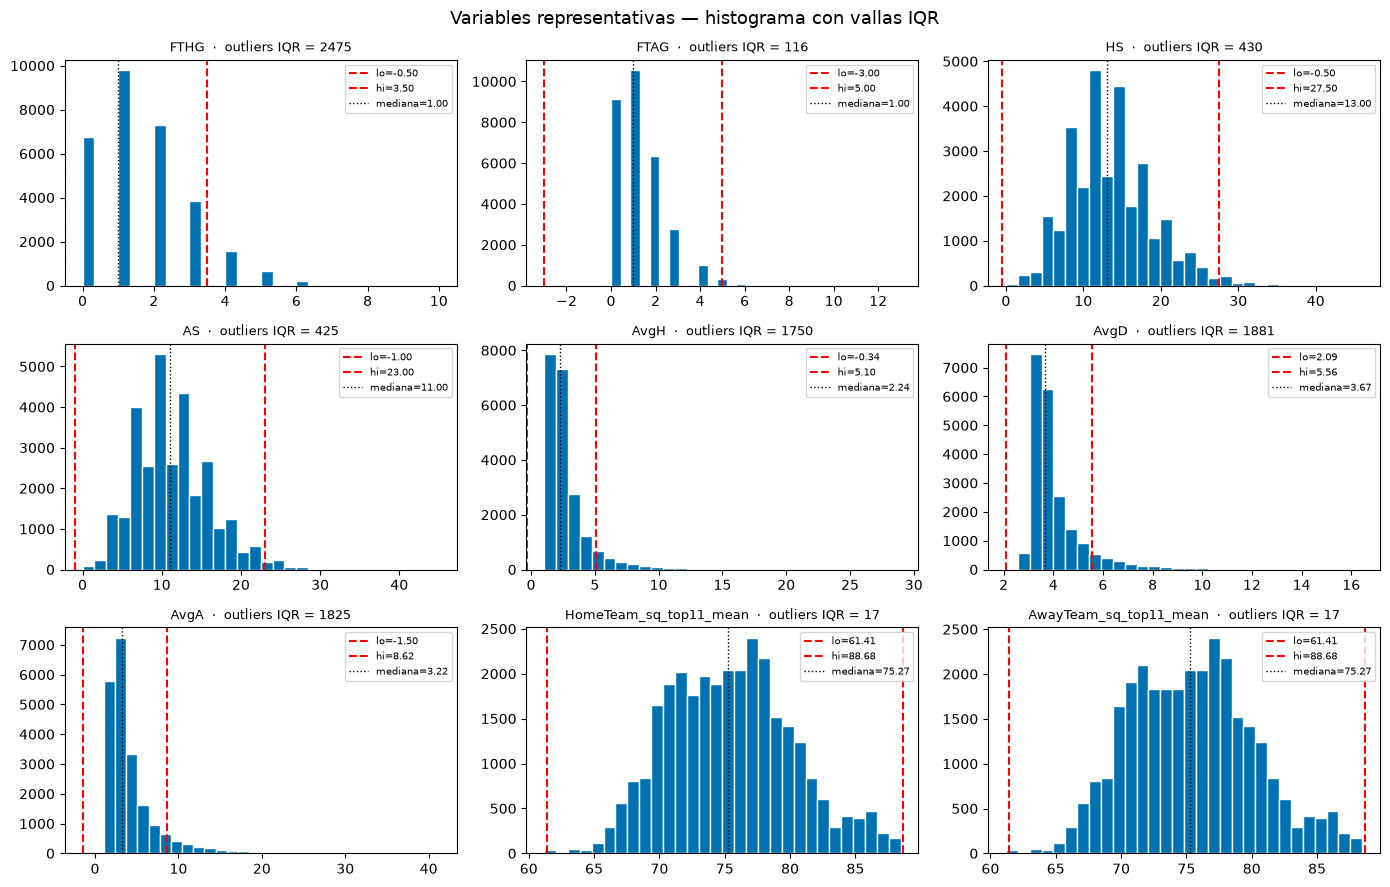

In [31]:
df_eda = df_clean.join(df[['AvgH', 'AvgD', 'AvgA']])

REPRESENTATIVAS = ['FTHG', 'FTAG', 'HS', 'AS', 'AvgH', 'AvgD', 'AvgA',
                   'HomeTeam_sq_top11_mean', 'AwayTeam_sq_top11_mean']
REPRESENTATIVAS = [c for c in REPRESENTATIVAS if c in df_eda.columns]

# Boxplot
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = np.atleast_2d(axes)
for ax, c in zip(axes.ravel(), REPRESENTATIVAS):
    s = df_eda[c].dropna()
    lo, hi = iqr_fences(s)
    nout = int(((s < lo) | (s > hi)).sum())
    ax.boxplot(s, vert=False, showfliers=True)
    ax.set_title(f"{c}  ·  outliers IQR = {nout}", fontsize=9)
for ax in axes.ravel()[len(REPRESENTATIVAS):]:
    ax.axis('off')
fig.suptitle('Variables representativas — boxplot (points = IQR outliers)', fontsize=13)
plt.tight_layout()
plt.show()

# Histograma + vallas IQR
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = np.atleast_2d(axes)
for ax, cx in zip(axes.ravel(), REPRESENTATIVAS):
    s = df_eda[cx].dropna()
    lo, hi = iqr_fences(s)
    nout = int(((s < lo) | (s > hi)).sum())
    ax.hist(s, bins=30, color='#0072B2', edgecolor='white')
    ax.axvline(lo, color='red', ls='--', lw=1.5, label=f'lo={lo:.2f}')
    ax.axvline(hi, color='red', ls='--', lw=1.5, label=f'hi={hi:.2f}')
    ax.axvline(s.median(), color='k', ls=':', lw=1, label=f'mediana={s.median():.2f}')
    ax.set_title(f"{cx}  ·  outliers IQR = {nout}", fontsize=9)
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(REPRESENTATIVAS):]:
    ax.axis('off')
fig.suptitle('Variables representativas — histograma con vallas IQR', fontsize=13)
plt.tight_layout()
plt.show()

**Lo que se observa:** los outliers en goles y tiros son extremos reales de partidos atípicos; en las cuotas (`AvgH`/`AvgD`/`AvgA`) son partidos muy desequilibrados (long-shots), justo donde se concentra el ROI en un backtest de *value bets*. Por
eso **no se eliminan ni se capan**.

Acá no las vamos a eliminar por estas razones:
1. **En cuotas son puros**: `AvgA` puede llegar a 41.2 (o `AvgH` a 29.0) porque es un “seguro” para la casa de apuestas, es decir equipo grande vs equipo chico. Es información real del mercado, no un error.
2. **En estadísticas son extremos reales**: 30+ tiros o 5+ goles son partidos atípicos pero reales.
3. **Un modelo calibrado los necesita**: este proyecto busca probabilidades y value bets; la cola de cuotas largas (long-shots) es justo donde se gana o se pierde el ROI. Eliminarlos o caparlos sesga las probabilidades predichas.

## Análisis Bivariado

Ahora estudiamos **pares de variables**: cómo las cuotas y la calidad de plantilla se relacionan con
el resultado real `FTR`. Esto revela la señal que aprovechará el modelo y motiva las decisiones de
ingeniería de features: qué variables son informativas, cuáles son redundantes y en qué orden de
importancia.

Vamos a ver si la **cuota media de mercado** (`AvgH`, `AvgD`, `AvgA`) distingue el
resultado real. Si el mercado es informativo, la cuota correspondiente al resultado ocurrido debería
ser menor (se estimó más probable). Agrupamos la cuota media por clase de `FTR` y dibujamos boxplots.

La media de mercado es el promedio 1X2 de las principales casas. Es virtualmente idéntica a las
cuotas de cierre de Pinnacle (`PSCH`/`PSCD`/`PSCA`): el acierto del favorito difiere en menos de
1 punto porcentual (53.9% vs 54.5%) y la información mutua con `FTR` es casi la misma (≈0.11 en
victorias locales/visitantes). Por cobertura y simplicidad, el modelo usa `Avg` como representación
del mercado.

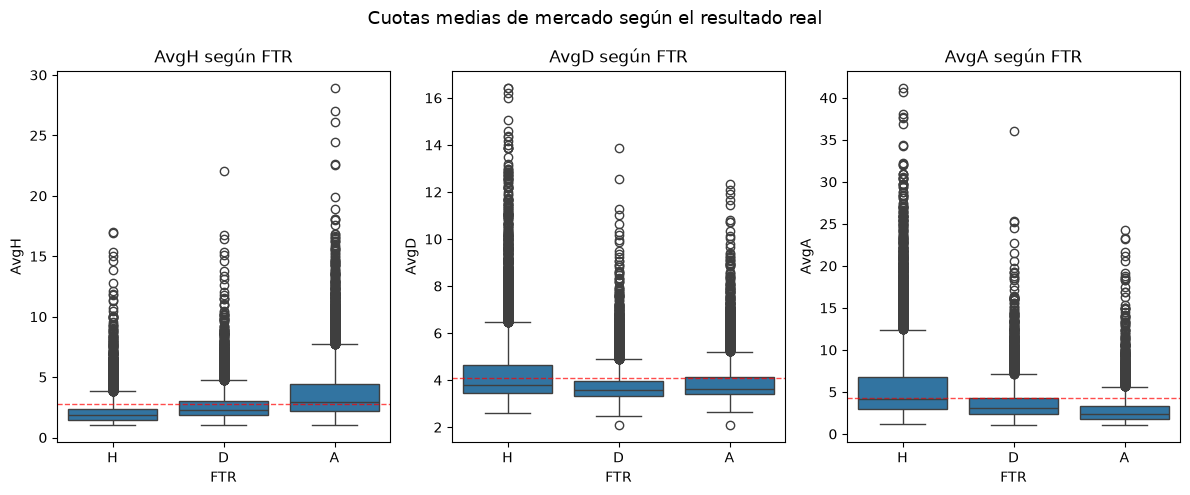

,AvgH,AvgD,AvgA
FTR,,,
A,3.707,3.917,2.878
D,2.678,3.809,3.763
H,2.121,4.333,5.624


In [32]:
df_eda = df_clean.join(df[['AvgH', 'AvgD', 'AvgA']])

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, cx in zip(axes, ['AvgH', 'AvgD', 'AvgA']):
    sns.boxplot(data=df_eda, x='FTR', y=cx, order=['H', 'D', 'A'], ax=ax)
    ax.axhline(df_eda[cx].mean(), color='red', ls='--', lw=1, alpha=0.7)
    ax.set_title(f'{cx} según FTR')
plt.suptitle('Cuotas medias de mercado según el resultado real', fontsize=13)
plt.tight_layout()
plt.show()

df_eda.groupby('FTR')[['AvgH', 'AvgD', 'AvgA']].mean().round(3)

**Lo que se observa:** cuando gana el local, `AvgH` es sustancialmente menor que cuando pierde, y `AvgA` cae cuando gana el visitante. Las cuotas medias de mercado anticipan el resultado con buena precisión: son la señal pre-partido más fuerte y el *baseline* del mercado. Son prácticamente equivalentes a las cuotas de cierre de Pinnacle, de modo que `Avg` es una representación compacta y suficiente del mercado.

Ahora la relación entre **squad quality** y resultado: creamos la diferencia de rating
del once ideal `local − visitante` (`HomeTeam_sq_top11_mean − AwayTeam_sq_top11_mean`). Si la
plantilla importa, la diferencia debería ser positiva cuando gana el local y negativa cuando gana el
visitante.

/tmp/ipykernel_137984/4198991839.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['diff_sq_top11'] = df_clean['HomeTeam_sq_top11_mean'] - df_clean['AwayTeam_sq_top11_mean']


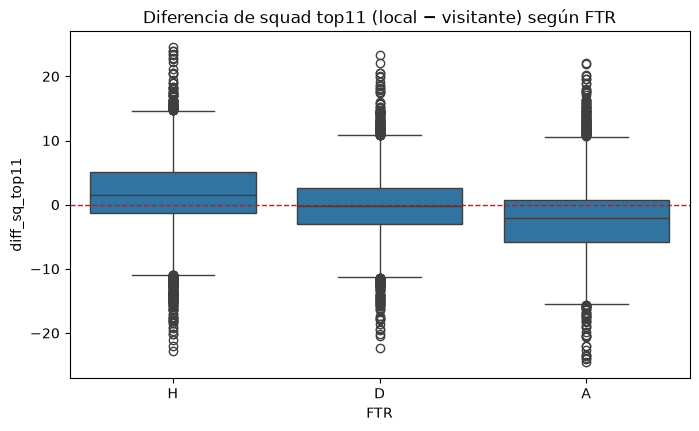

FTR
A   -2.32
D   -0.22
H    1.76
Name: diff_sq_top11, dtype: float64

In [33]:
df_clean['diff_sq_top11'] = df_clean['HomeTeam_sq_top11_mean'] - df_clean['AwayTeam_sq_top11_mean']

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df_clean, x='FTR', y='diff_sq_top11', order=['H', 'D', 'A'])
plt.axhline(0, color='red', ls='--', lw=1)
plt.title('Diferencia de squad top11 (local − visitante) según FTR')
plt.show()

df_clean.groupby('FTR')['diff_sq_top11'].mean().round(2)

**Lo que se observa:** cuando gana el local la diferencia media es positiva, cuando gana el visitante es negativa y el empate queda en el medio. La plantilla aporta señal complementaria a las cuotas, útil sobre todo a inicios de temporada cuando aún no hay historial de forma.

Finalmente, la **matriz de correlación de todas las variables numéricas de `df_clean`**: goles, tiros, cuotas medias, squad quality y banderas, para identificar relaciones lineales y **multicolinealidad** (variables que repiten información). Como son muchas columnas, primero el mapa completo en color y luego un detalle anotado de las variables clave (goles, tiros, cuotas medias de mercado y squad).

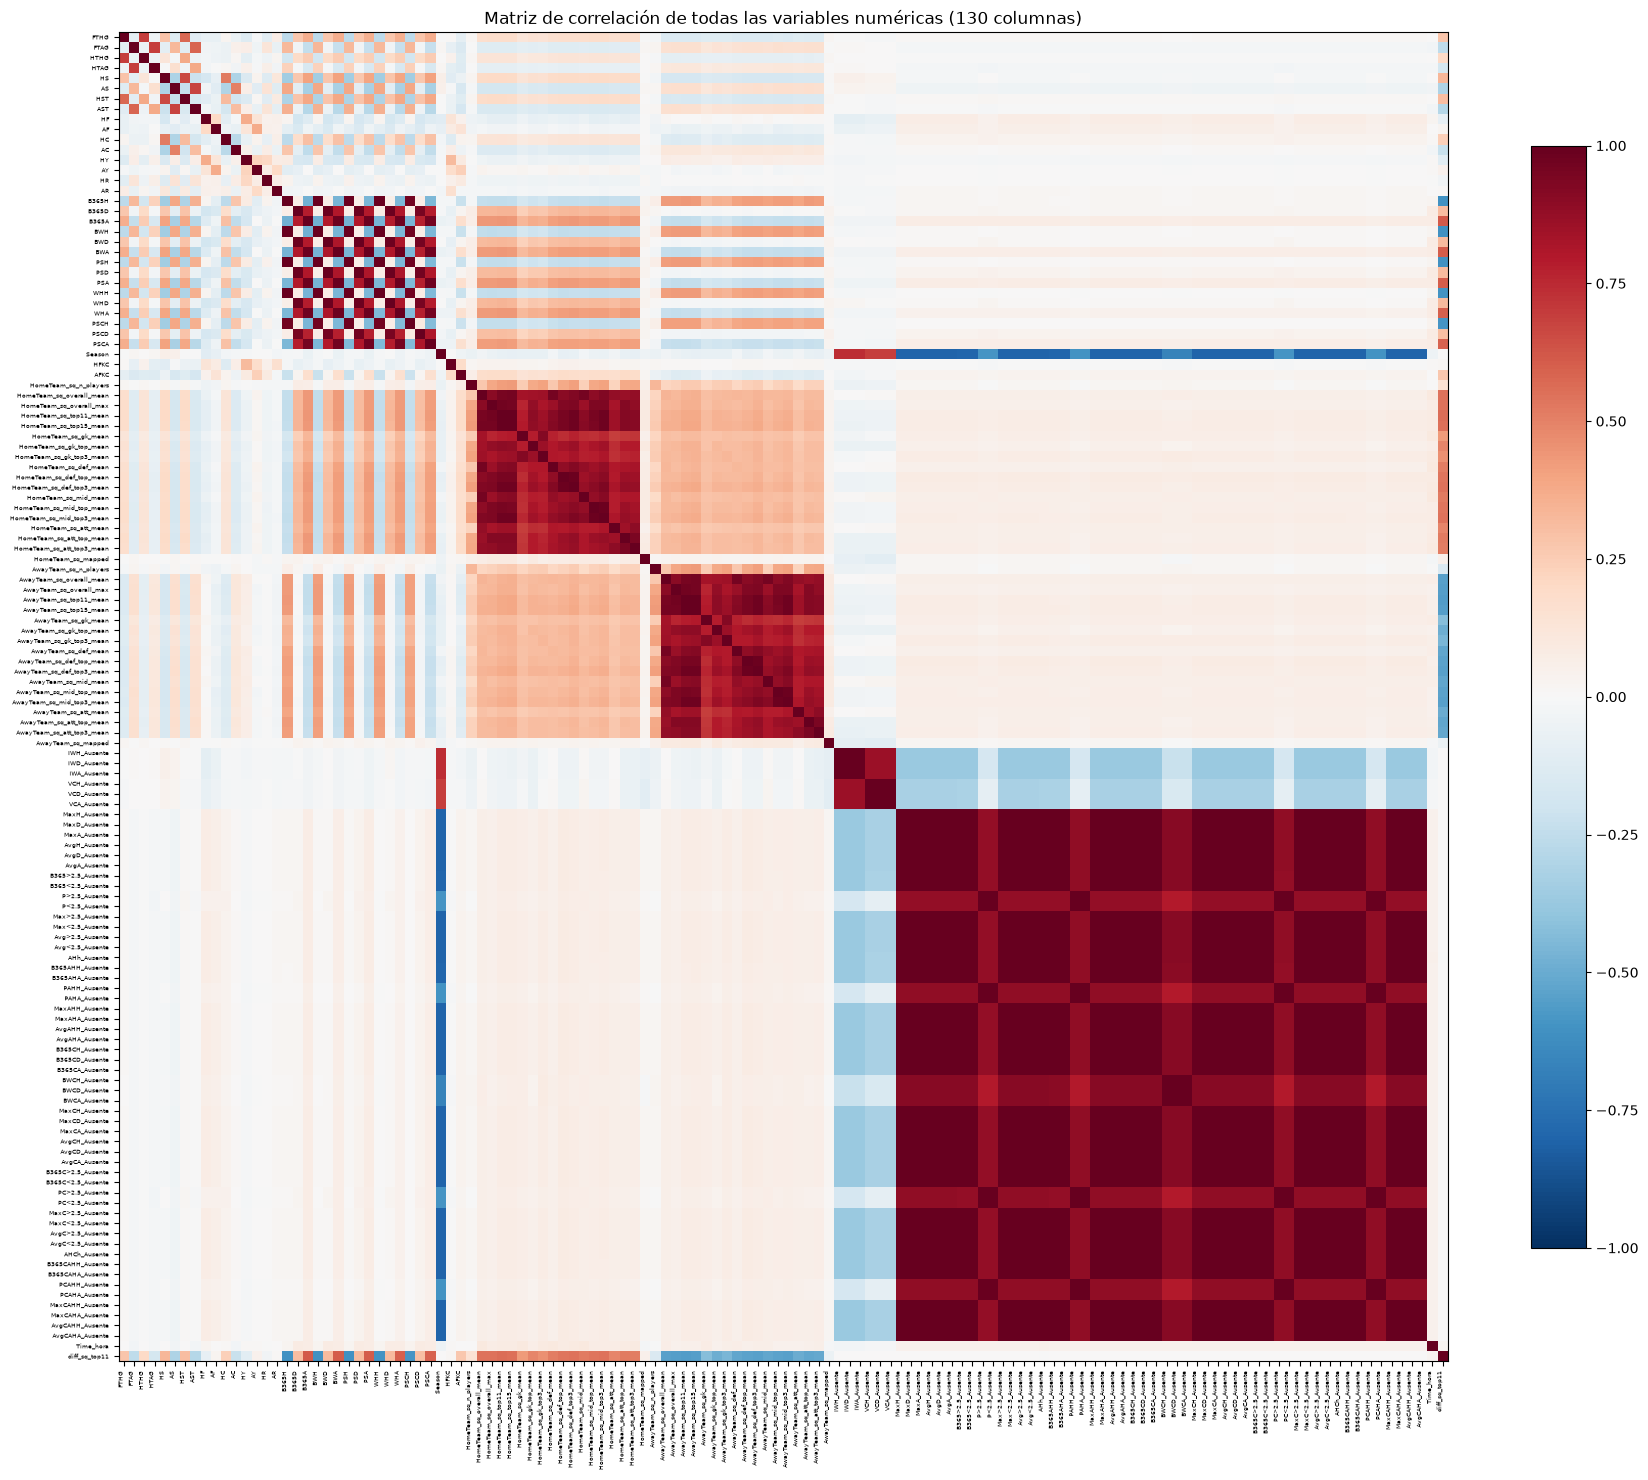

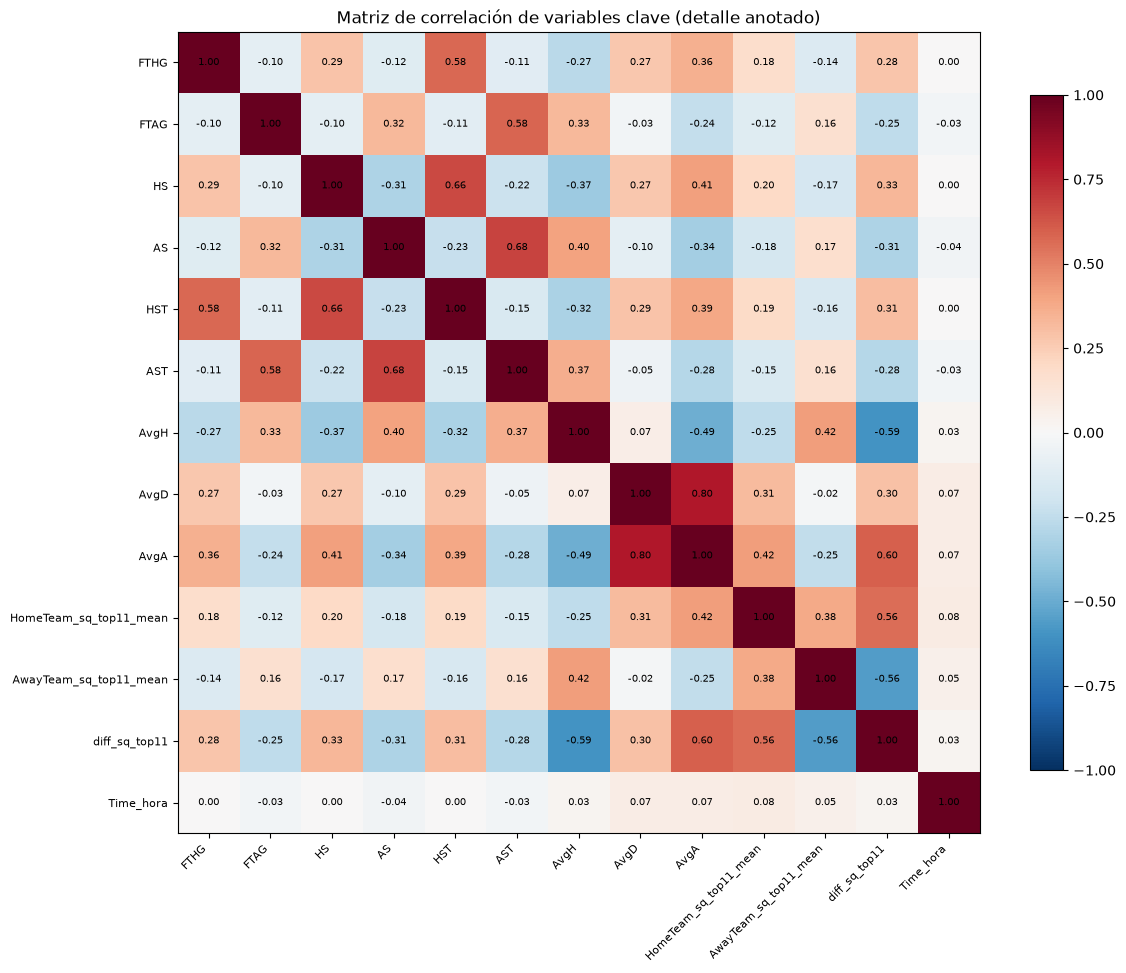

Columnas en la correlación total: 130


In [34]:
# 1) Correlación de TODAS las variables numéricas (mapa de color, sin anotaciones)
corr_total = df_clean.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(corr_total, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_total))); ax.set_xticklabels(corr_total.columns, rotation=90, ha='right', fontsize=4)
ax.set_yticks(range(len(corr_total))); ax.set_yticklabels(corr_total.columns, fontsize=4)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'Matriz de correlación de todas las variables numéricas ({len(corr_total)} columnas)')
plt.tight_layout()
plt.show()

# 2) Detalle anotado de las variables clave (legible) en la media de mercado, no las cuotas por casa
df_eda = df_clean.join(df[['AvgH', 'AvgD', 'AvgA']])
corr_var = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'AvgH', 'AvgD', 'AvgA',
            'HomeTeam_sq_top11_mean', 'AwayTeam_sq_top11_mean', 'diff_sq_top11', 'Time_hora']
corr_var = [c for c in corr_var if c in df_eda.columns]
corr = df_eda[corr_var].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for a in range(len(corr)):
    for b in range(len(corr)):
        ax.text(b, a, f'{corr.iloc[a, b]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de correlación de variables clave (detalle anotado)')
plt.tight_layout()
plt.show()

print('Columnas en la correlación total:', len(corr_total))

**Lo que se observa:** las cuotas de distintas casas/momentos correlacionan muy alto
(|r| > 0.9), lo que justifica la imputación con KNN y, en la ingeniería de features, conservar solo
la media del mercado (`AvgH`/`AvgD`/`AvgA`, re-creadas desde el dataset crudo) como referencia única.
Goles y tiros correlacionan positivamente (r ≈ 0.6–0.7) y la squad correlaciona poco con las cuotas →
señal complementaria.

## Análisis Multivariado (exploración)

Cerramos el análisis exploratorio mirando **varias variables a la vez**: un scatter matrix de las
variables clave coloreadas por `FTR` y una PCA sobre las cuotas medias de mercado para visualizar la
estructura del mercado frente al resultado.

Vamos a construir un **scatter matrix** (pares de variables) de goles, cuotas medias
y squad, coloreando cada punto según el resultado `FTR`: así vemos la separación conjunta de las tres
clases. Para que sea legible muestreamos 5000 partidos.

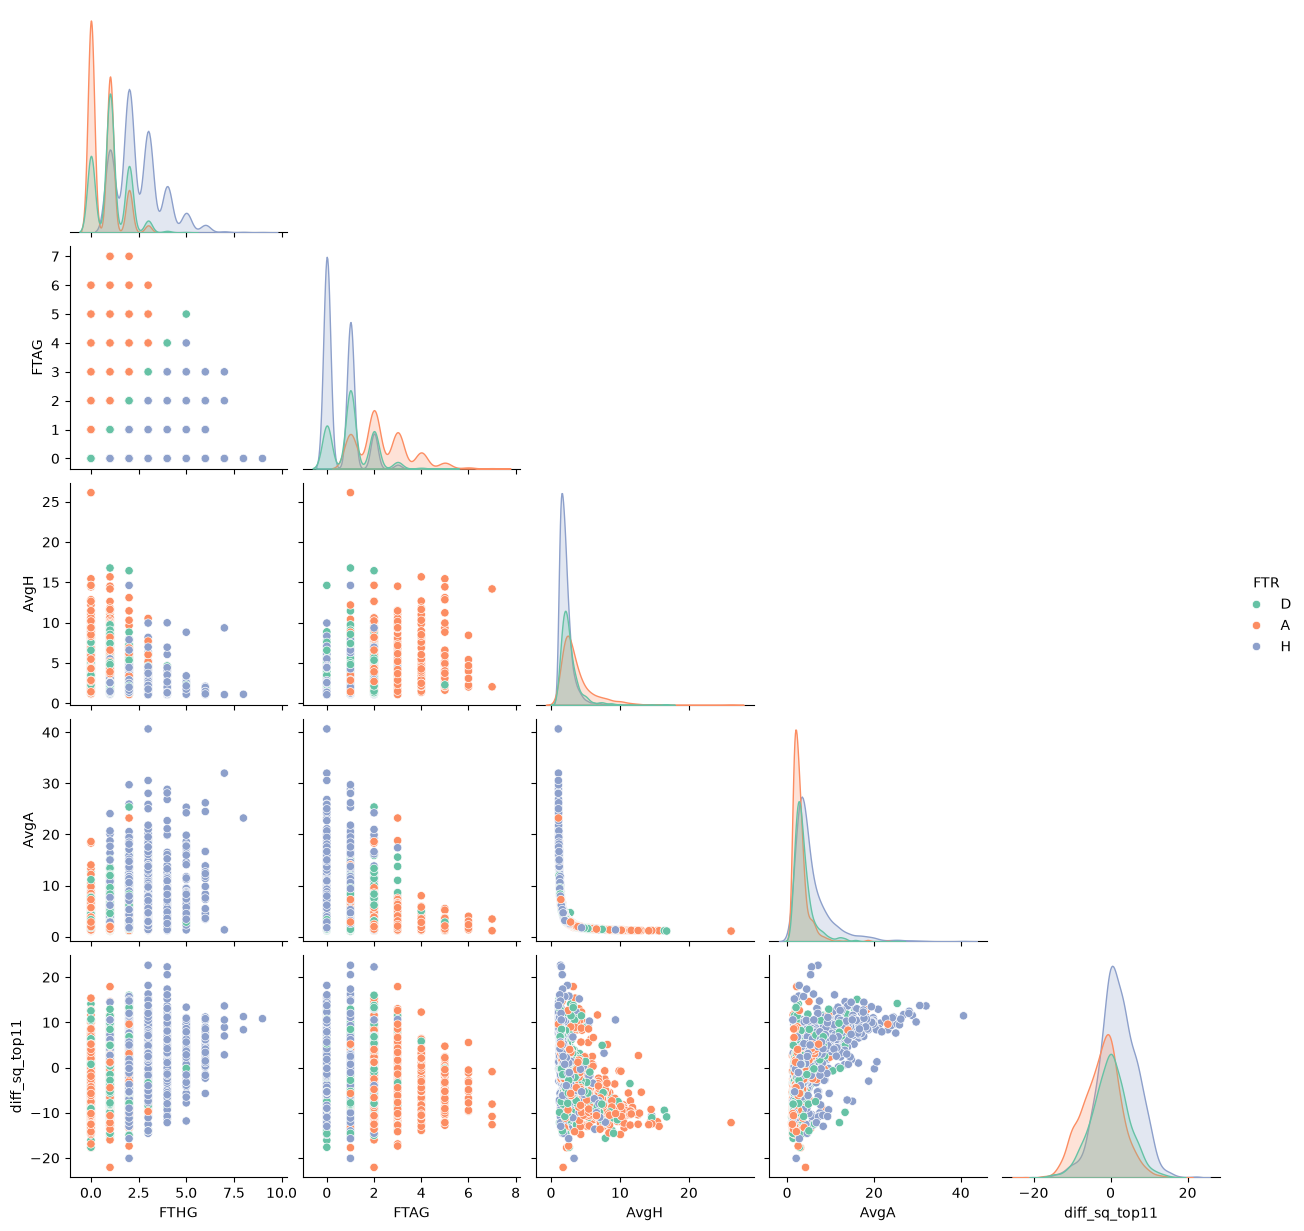

In [35]:
df_eda = df_clean.join(df[['AvgH', 'AvgD', 'AvgA']])

sns.pairplot(
    df_eda[['FTHG', 'FTAG', 'AvgH', 'AvgA', 'diff_sq_top11']].assign(FTR=df_eda['FTR']).sample(5000, random_state=42),
    hue='FTR', palette='Set2', diag_kind='kde', corner=True)
plt.show()

**Lo que se observa:** las clases se solapan bastante (el fútbol es ruidoso), pero los
pares `FTHG`/`FTAG` con `AvgA`/`AvgH` muestran la mejor separación parcial; la squad (`diff_sq_top11`)
aporta fronteras más difusas.

Ahora una **PCA sobre las cuotas medias de mercado** (variables altamente
correlacionadas) para comprimir el mercado en 2 componentes y ver si el resultado se estructura a lo
largo de ellas.

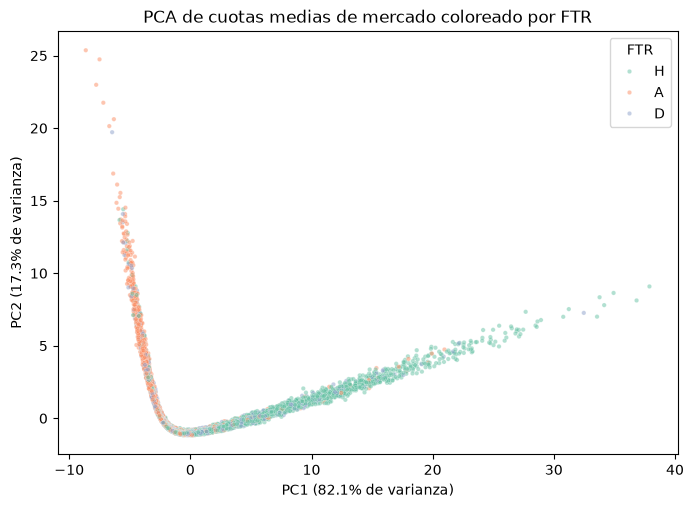

Varianza explicada: [82.1 17.3]


In [36]:
from sklearn.decomposition import PCA

Xp = df[['AvgH', 'AvgD', 'AvgA']].dropna()
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(Xp)

plt.figure(figsize=(8, 5.5))
sns.scatterplot(x=pc[:, 0], y=pc[:, 1],
                hue=df_clean.loc[Xp.index, 'FTR'], palette='Set2', alpha=0.5, s=10)
plt.title('PCA de cuotas medias de mercado coloreado por FTR')
plt.xlabel(f'PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}% de varianza)')
plt.ylabel(f'PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}% de varianza)')
plt.legend(title='FTR')
plt.show()

print('Varianza explicada:', (pca.explained_variance_ratio_ * 100).round(1))

**Lo que se observa:** los dos primeros componentes explican prácticamente toda la
varianza del mercado 1X2 (las cuotas son casi colineales, evidencia de multicolinealidad). Los
partidos con cuota de local muy baja (favorito claro, extremo de PC1) se concentran en victorias
locales; la nube central corresponde a partidos equilibrados y empates.